# Spaceship Titanic: The Story in the Data

In the year 2912, the interstellar liner Spaceship Titanic collided with a spacetime anomaly and almost half of its passengers were transported to another dimension.

**Question:** which passengers were transported (`Transported`), and can a model learn why?

| | Titanic | Spaceship Titanic |
|---|---|---|
| The event | 1912, the ship hits an iceberg and sinks | 2912, the spaceship hits a spacetime anomaly |
| What happens to the passengers? | Some die, some are rescued | About half are transported to another dimension |
| Prediction | `Survived`: did they survive? | `Transported`: were they transported? |
| Records | Age, sex, class, ticket | Home planet, cabin, sleep status, spending |

Rescue crews are trying to work out who was lost from the records recovered off the ship's damaged computer. That is our job too: a yes/no prediction for every passenger.

**One important difference:** the Titanic was a real event, so hypotheses like "women and children first" came from history. Spaceship Titanic is fiction and nobody knows how the anomaly works. So we learn the rules from the **data**, not from history.

## Chapter 1: Getting to Know the Data

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.grid.axis"] = "y"

# Chart colors: blue = not transported, orange = transported, gray = single measure
TARGET_COLORS = {False: "#2a78d6", True: "#eb6834"}
TARGET_LABELS = {False: "Not transported", True: "Transported"}
NEUTRAL = "#6b6a65"
INK = "#52514e"
RATE_LABEL = "Transported rate"


def label_bars(ax, fmt="{:.0%}"):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9, color=INK)


def rate_bar(ax, rates, title, xlabel):
    ax.bar(rates.index.astype(str), rates.values, color=NEUTRAL, width=0.6)
    ax.axhline(train_raw["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
    label_bars(ax)
    ax.set(ylim=(0, 1.05), title=title, xlabel=xlabel, ylabel=RATE_LABEL)

# Local: dataset/  ·  Kaggle: /kaggle/input/...
KAGGLE_INPUT = Path("/kaggle/input")
DATA_DIR = next(KAGGLE_INPUT.rglob("train.csv")).parent if KAGGLE_INPUT.exists() else Path("dataset")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
print(f"Data: {DATA_DIR}")
train_raw.head()

Data: dataset


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00,True,43.00,"3,576.00",0.00,"6,715.00",49.00,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00,False,0.00,"1,283.00",371.00,"3,329.00",193.00,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,Willy Santantines,True


### 1.1 Rows and columns

In [2]:
pd.DataFrame(
    {"rows": [len(train_raw), len(test_raw)], "columns": [train_raw.shape[1], test_raw.shape[1]]},
    index=["train", "test"],
)

,rows,columns
train,8693,14
test,4277,13


In [3]:
# The only column missing from test should be the target
set(train_raw.columns) - set(test_raw.columns)

{'Transported'}

### 1.2 What do the columns mean?

| Column | Meaning |
|---|---|
| `PassengerId` | `gggg_pp`: `gggg` is the group the passenger travels with, `pp` their number inside it. A group is often a family, but not always |
| `HomePlanet` | The planet the passenger departed from, usually where they permanently live |
| `CryoSleep` | Was the passenger in suspended animation for the voyage? Sleepers stay confined to their cabins |
| `Cabin` | `deck/num/side`: deck / cabin number / side (`P` = Port, `S` = Starboard) |
| `Destination` | The planet the passenger is heading for |
| `Age` | Age |
| `VIP` | Did the passenger pay for VIP service? |
| `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` | Amount billed at the ship's luxury amenities |
| `Name` | First and last name |
| `Transported` | **Target:** was the passenger transported to another dimension? |

### 1.3 Data types

In [4]:
def column_overview(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "known": df.notna().sum(),
        "missing": df.isna().sum(),
        "unique": df.nunique(),
        "example": df.apply(lambda s: s.dropna().iloc[0]),
    })

column_overview(train_raw)

,dtype,known,missing,unique,example
PassengerId,object,8693,0,8693,0001_01
HomePlanet,object,8492,201,3,Europa
CryoSleep,object,8476,217,2,False
Cabin,object,8494,199,6560,B/0/P
Destination,object,8511,182,3,TRAPPIST-1e
Age,float64,8514,179,80,39.00
VIP,object,8490,203,2,False
RoomService,float64,8512,181,1273,0.00
FoodCourt,float64,8510,183,1507,0.00
ShoppingMall,float64,8485,208,1115,0.00


In [5]:
# What do the object columns actually hold?
for col in ["CryoSleep", "VIP"]:
    print(col, train_raw[col].map(type).value_counts(dropna=False).to_dict())

CryoSleep {<class 'bool'>: 8476, <class 'float'>: 217}
VIP {<class 'bool'>: 8490, <class 'float'>: 203}


**Type conversion:** `CryoSleep` and `VIP` carry True/False values together with missing ones (`NaN`), so pandas read them as `object`. We convert them to the `boolean` dtype, which keeps missing values. The text columns (`HomePlanet`, `Destination`) become `category`. `Cabin`, `PassengerId` and `Name` each pack several pieces of information together; splitting them is left to the preprocessing step.

In [6]:
BOOL_COLS = ["CryoSleep", "VIP"]
CAT_COLS = ["HomePlanet", "Destination"]
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM_COLS = ["Age"] + SPEND_COLS


def convert_types(df):
    df = df.copy()
    df[BOOL_COLS] = df[BOOL_COLS].astype("boolean")
    df[CAT_COLS] = df[CAT_COLS].astype("category")
    return df


train = convert_types(train_raw)
test = convert_types(test_raw)
pd.DataFrame({"before": train_raw.dtypes.astype(str), "after": train.dtypes.astype(str)})

,before,after
PassengerId,object,object
HomePlanet,object,category
CryoSleep,object,boolean
Cabin,object,object
Destination,object,category
Age,float64,float64
VIP,object,boolean
RoomService,float64,float64
FoodCourt,float64,float64
ShoppingMall,float64,float64


### 1.4 Duplicate records

In [7]:
full = pd.concat([train.drop(columns="Transported"), test], keys=["train", "test"])

pd.Series({
    "identical rows (train)": train.duplicated().sum(),
    "duplicate PassengerId (train + test)": full["PassengerId"].duplicated().sum(),
    "identical rows apart from the ID (train + test)": full.drop(columns="PassengerId").duplicated().sum(),
    "duplicate names (train + test, known)": full["Name"].dropna().duplicated().sum(),
})

identical rows (train)                              0
duplicate PassengerId (train + test)                0
identical rows apart from the ID (train + test)     0
duplicate names (train + test, known)              47
dtype: int64

In [8]:
# Are passengers with the same name the same person?
same_name = full[full["Name"].notna() & full["Name"].duplicated(keep=False)].sort_values("Name")
same_name.head(6)

PassengerId HomePlanet  CryoSleep    Cabin  Destination   Age  \
train 2404     2589_01     Europa       True   C/91/P  TRAPPIST-1e 26.00   
test  593      1219_02     Europa       True   B/52/S  55 Cancri e 23.00   
train 6296     6665_01     Europa       True  B/222/P  55 Cancri e 17.00   
      7270     7775_01     Europa      False  C/253/P  55 Cancri e 28.00   
      2930     3176_01     Europa      False  E/196/P  TRAPPIST-1e 77.00   
      476      0512_02     Europa       True   D/18/S  TRAPPIST-1e 55.00   

              VIP  RoomService  FoodCourt  ShoppingMall    Spa   VRDeck  \
train 2404  False         0.00       0.00          0.00   0.00     0.00   
test  593   False         0.00       0.00          0.00   0.00     0.00   
train 6296  False         0.00       0.00          0.00   0.00     0.00   
      7270  False         7.00     489.00          0.00   4.00 6,027.00   
      2930  False         0.00   9,032.00          0.00 128.00 1,464.00   
      476   False         0.00       0.00          0.00   0.00     0.00   

                          Name  
train 2404      Alasmon Meteet  
test  593       Alasmon Meteet  
train 6296  Alraium Disivering  
      7270  Alraium Disivering  
      2930  Ankalik Nateansive  
      476   Ankalik Nateansive

### 1.5 Missing values

In [9]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_%": train.isna().mean() * 100,
    "test_missing": test.isna().sum(),
    "test_%": test.isna().mean() * 100,
}).drop(index="Transported").astype({"test_missing": int}).sort_values("train_%", ascending=False)
missing

,train_missing,train_%,test_missing,test_%
CryoSleep,217,2.50,93,2.17
ShoppingMall,208,2.39,98,2.29
VIP,203,2.34,93,2.17
HomePlanet,201,2.31,87,2.03
Name,200,2.30,94,2.20
Cabin,199,2.29,100,2.34
VRDeck,188,2.16,80,1.87
FoodCourt,183,2.11,106,2.48
Spa,183,2.11,101,2.36
Destination,182,2.09,92,2.15


In [10]:
# How many columns are missing for a single passenger?
per_row = pd.DataFrame({
    "train": train.drop(columns="Transported").isna().sum(axis=1).value_counts(),
    "test": test.isna().sum(axis=1).value_counts(),
}).fillna(0).astype(int)
per_row.index.name = "missing columns"
per_row

,train,test
missing columns,,
0,6606,3281
1,1867,879
2,203,113
3,17,4


In [11]:
# What would we lose by dropping rows with gaps?
dropped = train.dropna()
pd.Series({
    "train rows": len(train),
    "complete rows": len(dropped),
    "rows that would be dropped": len(train) - len(dropped),
    "share lost %": round((1 - len(dropped) / len(train)) * 100, 1),
    "test rows with a gap": test.isna().any(axis=1).sum(),
}, dtype=object)

train rows                    8693
complete rows                 6606
rows that would be dropped    2087
share lost %                 24.00
test rows with a gap           996
dtype: object

### 1.6 Basic statistics

In [12]:
num = train[NUM_COLS]
pd.DataFrame({
    "mean": num.mean(),
    "median": num.median(),
    "std": num.std(),
    "min": num.min(),
    "%25": num.quantile(0.25),
    "%75": num.quantile(0.75),
    "max": num.max(),
    "zeros %": (num == 0).mean() * 100,
    "skew": num.skew(),
})

,mean,median,std,min,%25,%75,max,zeros %,skew
Age,28.83,27.00,14.49,0.00,19.00,38.00,79.00,2.05,0.42
RoomService,224.69,0.00,666.72,0.00,0.00,47.00,"14,327.00",64.16,6.33
FoodCourt,458.08,0.00,"1,611.49",0.00,0.00,76.00,"29,813.00",62.76,7.10
ShoppingMall,173.73,0.00,604.70,0.00,0.00,27.00,"23,492.00",64.27,12.63
Spa,311.14,0.00,"1,136.71",0.00,0.00,59.00,"22,408.00",61.24,7.64
VRDeck,304.85,0.00,"1,145.72",0.00,0.00,46.00,"24,133.00",63.21,7.82


In [13]:
# Categorical and boolean columns: value distributions (%)
for col in CAT_COLS + BOOL_COLS + ["Transported"]:
    print(f"\n{col}")
    print((train[col].value_counts(dropna=False, normalize=True) * 100).round(1).to_string())


HomePlanet
HomePlanet
Earth    52.90
Europa   24.50
Mars     20.20
NaN       2.30

Destination
Destination
TRAPPIST-1e     68.00
55 Cancri e     20.70
PSO J318.5-22    9.20
NaN              2.10

CryoSleep
CryoSleep
False   62.60
True    34.90
<NA>     2.50

VIP
VIP
False   95.40
<NA>     2.30
True     2.30

Transported
Transported
True    50.40
False   49.60


### 1.7 Two questions about the gaps

- **Is the missingness random?** If passengers with and without a missing value are transported at the same rate, a gap carries no signal of its own.
- **Can the gaps be inferred from other columns?** A sleeping passenger cannot spend anything; people travelling in the same group come from the same planet.

### 1.8 Is missingness related to being transported?

In [14]:
rows = []
for col in train.columns.drop(["PassengerId", "Transported"]):
    miss = train[col].isna()
    rows.append({
        "column": col,
        "missing n": miss.sum(),
        "transported % (missing)": train.loc[miss, "Transported"].mean() * 100,
        "transported % (known)": train.loc[~miss, "Transported"].mean() * 100,
    })
pd.DataFrame(rows).set_index("column")

,missing n,transported % (missing),transported % (known)
column,,,
HomePlanet,201,51.24,50.34
CryoSleep,217,48.85,50.40
Cabin,199,50.25,50.36
Destination,182,50.55,50.36
Age,179,50.28,50.36
VIP,203,51.23,50.34
RoomService,181,45.86,50.46
FoodCourt,183,54.10,50.28
ShoppingMall,208,54.81,50.25


### 1.9 Can the gaps be inferred from other columns?

First we split the packed columns, for analysis only. None of these relationships use the target, so train and test can be examined together.

In [15]:
def split_columns(df):
    df = df.copy()
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["PassengerId"].transform("count")
    df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)
    df["Surname"] = df["Name"].str.split().str[-1]
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, min_count=1)
    return df


full = split_columns(pd.concat([train.drop(columns="Transported"), test], ignore_index=True))


def group_rule(col, key):
    # Is col always the same inside a key? How often can a missing col be filled from the key?
    known = full[full[col].notna() & full[key].notna()]
    n_unique = known.groupby(key)[col].nunique()
    multi = known.groupby(key).size() >= 2
    fill_value = known.groupby(key)[col].agg(lambda s: s.mode().iloc[0])
    missing = full[full[col].isna()]
    return {
        "rule": f"{key} → {col}",
        "consistency % (groups of ≥2)": (n_unique[multi] == 1).mean() * 100,
        "missing": len(missing),
        "fillable": missing[key].map(fill_value).notna().sum(),
    }


pd.DataFrame([
    group_rule("HomePlanet", "Group"),
    group_rule("HomePlanet", "Surname"),
    group_rule("Destination", "Group"),
    group_rule("Cabin", "Group"),
    group_rule("Deck", "Group"),
    group_rule("Side", "Group"),
    group_rule("Surname", "Group"),
    group_rule("VIP", "Group"),
]).set_index("rule")

,consistency % (groups of ≥2),missing,fillable
rule,,,
Group → HomePlanet,100.00,288,131
Surname → HomePlanet,100.00,288,271
Group → Destination,48.46,274,120
Group → Cabin,67.46,299,137
Group → Deck,67.46,299,137
Group → Side,100.00,299,137
Group → Surname,82.33,294,139
Group → VIP,92.98,296,124


**CryoSleep ↔ spending:** can a sleeping passenger spend anything?

In [16]:
pd.crosstab(full["CryoSleep"], full["TotalSpend"] > 0, dropna=False,
            rownames=["CryoSleep"], colnames=["spend > 0"])

spend > 0,False,True
CryoSleep,,
False,740,7339
True,4581,0
<NA>,136,174


In [17]:
cryo_missing = full[full["CryoSleep"].isna()]
spend_missing = full[SPEND_COLS].isna().any(axis=1)
pd.Series({
    "CryoSleep missing": len(cryo_missing),
    "  spend > 0 → False": (cryo_missing["TotalSpend"] > 0).sum(),
    "  spend 0 → could be True": (cryo_missing["TotalSpend"] == 0).sum(),
    "rows with a missing spending column": spend_missing.sum(),
    "  CryoSleep = True → 0": (spend_missing & (full["CryoSleep"] == True)).sum(),
    "  Age < 13 → 0": (spend_missing & (full["Age"] < 13)).sum(),
})

CryoSleep missing                       310
  spend > 0 → False                     174
  spend 0 → could be True               136
rows with a missing spending column    1363
  CryoSleep = True → 0                  513
  Age < 13 → 0                          127
dtype: int64

In [18]:
# CryoSleep share among non-spenders: how safe is it to set a missing CryoSleep to True?
no_spend = full[full["TotalSpend"] == 0]
(no_spend["CryoSleep"].value_counts(normalize=True, dropna=False) * 100).round(1)

CryoSleep
True    83.90
False   13.60
<NA>     2.50
Name: proportion, dtype: Float64

**Age and spending:** do children spend?

In [19]:
age_band = pd.cut(full["Age"], [-1, 12, 17, 25, 40, 60, 80], labels=["0-12", "13-17", "18-25", "26-40", "41-60", "61+"])
full.groupby(age_band, observed=True).agg(
    n=("Age", "size"),
    spenders_pct=("TotalSpend", lambda s: (s > 0).mean() * 100),
    median_spend=("TotalSpend", "median"),
)

,n,spenders_pct,median_spend
Age,,,
0-12,1157,0.00,0.00
13-17,1107,50.95,265.00
18-25,3627,66.64,724.00
26-40,4248,64.41,846.50
41-60,2234,64.37,811.50
61+,327,66.36,870.00


**Deck → home planet:** do some decks carry passengers from a single planet?

In [20]:
(pd.crosstab(full["Deck"], full["HomePlanet"], normalize="index") * 100).round(1).assign(
    n=full["Deck"].value_counts()
)

HomePlanet,Earth,Europa,Mars,n
Deck,,,,
A,0.00,100.00,0.00,354
B,0.00,100.00,0.00,1141
C,0.00,100.00,0.00,1102
D,0.00,42.20,57.80,720
E,45.30,15.30,39.40,1323
F,58.60,0.00,41.40,4239
G,100.00,0.00,0.00,3781
T,0.00,100.00,0.00,11


**VIP:** who is a VIP?

In [21]:
full.groupby("HomePlanet", observed=True)["VIP"].agg(VIP_pct=lambda s: s.mean() * 100, n="size").assign(
    VIP_pct=lambda d: d["VIP_pct"].round(2)
).T

HomePlanet,Earth,Europa,Mars
VIP_pct,0.00,5.78,3.43
n,6865,3133,2684


In [22]:
# Age: median by planet and spending state
full.pivot_table(index="HomePlanet", columns=full["TotalSpend"] > 0, values="Age",
                 aggfunc="median", observed=True).rename(columns={False: "no spending", True: "spending"})

TotalSpend,no spending,spending
HomePlanet,,
Earth,19.00,25.00
Europa,30.00,34.00
Mars,25.00,29.00


## Chapter 2: Who Was Transported?

The anomaly was a physical event: **where you were** and **what you were doing** at the moment of impact may both matter. Every hypothesis is examined in three steps: **intuition** (why it might work), **data** (tables and charts), **verdict** (confirmed or not).

50.4% of the passengers were transported; the dashed line in the charts marks that average.

### 2.1 Awake or asleep?

**Intuition:** a passenger in CryoSleep spends the whole voyage in their pod, inside their cabin. A passenger who spends money is awake and moving around the ship's spa, restaurants and shops. The anomaly may have hit the two groups differently.

In [23]:
spend_total = train[SPEND_COLS].sum(axis=1)
awake = train.assign(
    state=np.select(
        [train["CryoSleep"].fillna(False).astype(bool), spend_total == 0],
        ["Asleep", "Awake, no spending"],
        "Awake, spending",
    )
)
awake = awake[train["CryoSleep"].notna()]
awake.groupby("state")["Transported"].agg(transported_rate="mean", passengers="size").sort_values("transported_rate")

,transported_rate,passengers
state,,
"Awake, spending",0.30,4921
"Awake, no spending",0.62,518
Asleep,0.82,3037


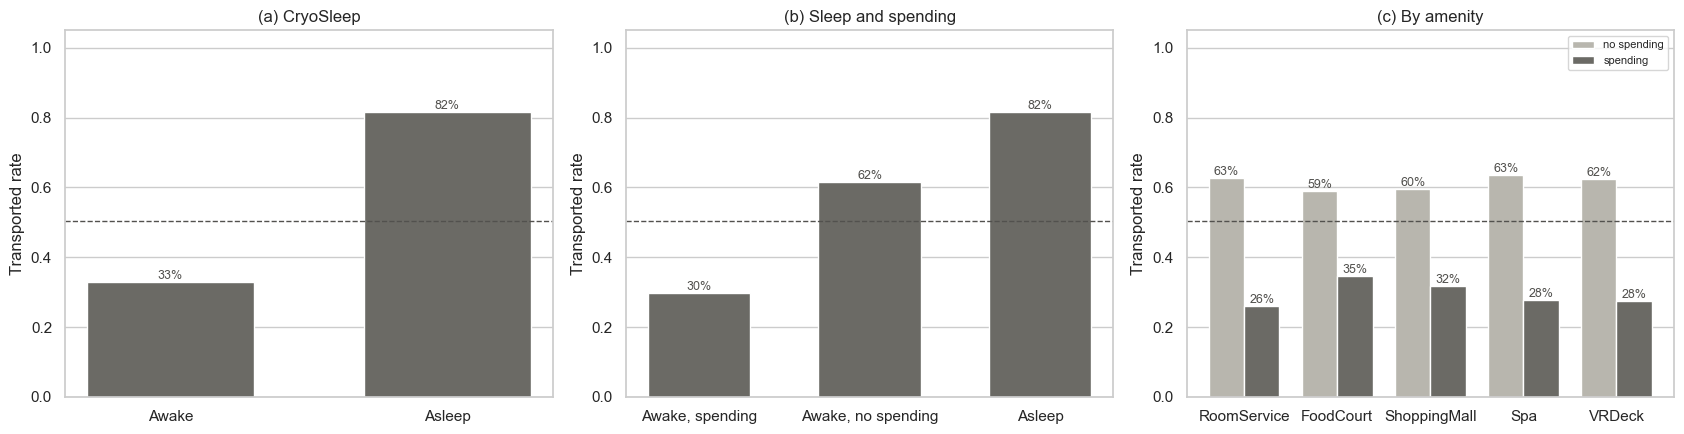

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

rate_bar(axes[0], train.groupby("CryoSleep")["Transported"].mean().rename({False: "Awake", True: "Asleep"}),
         "(a) CryoSleep", "")

order = ["Awake, spending", "Awake, no spending", "Asleep"]
rate_bar(axes[1], awake.groupby("state")["Transported"].mean().reindex(order), "(b) Sleep and spending", "")

# (c) For each amenity: transported rate of spenders and non-spenders
ax = axes[2]
by_service = pd.DataFrame({
    col: train.groupby(train[col] > 0)["Transported"].mean() for col in SPEND_COLS
}).T.rename(columns={False: "no spending", True: "spending"})
x, width = np.arange(len(SPEND_COLS)), 0.38
ax.bar(x - width / 2, by_service["no spending"], width, color="#b8b6ae", label="no spending")
ax.bar(x + width / 2, by_service["spending"], width, color=NEUTRAL, label="spending")
label_bars(ax)
ax.set_xticks(x, SPEND_COLS)
ax.axhline(train["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
ax.set(ylim=(0, 1.05), title="(c) By amenity", ylabel=RATE_LABEL)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

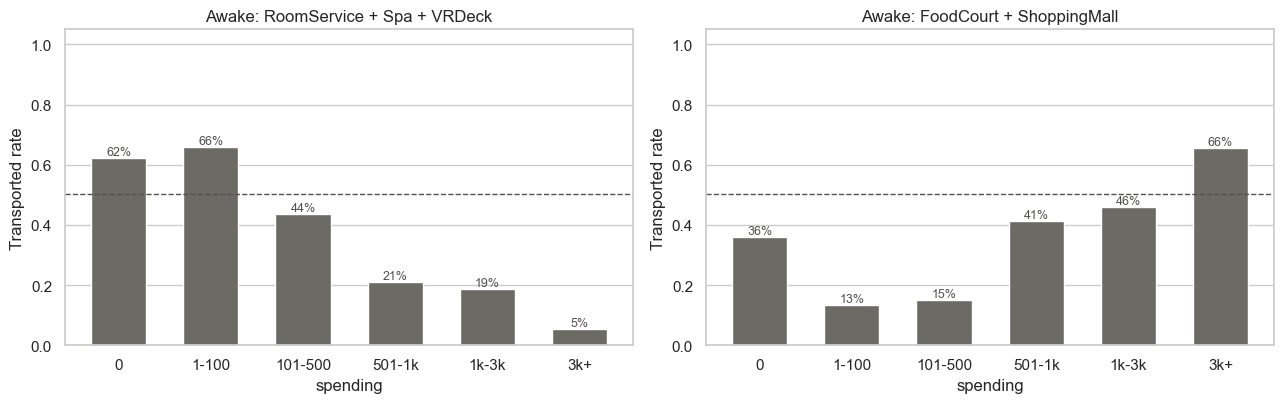

In [25]:
# (d) Among the awake: how does the transported rate move with spending, and with which amenity?
awake_spenders = train[(train["CryoSleep"] == False)]
luxury = ["RoomService", "Spa", "VRDeck"]
basic = ["FoodCourt", "ShoppingMall"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, cols, name in [(axes[0], luxury, "RoomService + Spa + VRDeck"), (axes[1], basic, "FoodCourt + ShoppingMall")]:
    total = awake_spenders[cols].sum(axis=1)
    bands = pd.cut(total, [-1, 0, 100, 500, 1000, 3000, np.inf], labels=["0", "1-100", "101-500", "501-1k", "1k-3k", "3k+"])
    rate_bar(ax, awake_spenders.groupby(bands, observed=True)["Transported"].mean(), f"Awake: {name}", "spending")
plt.tight_layout()
plt.show()

**Verdict: confirmed, the strongest signal in the data.**

- **82%** of the sleepers were transported, against 33% of those awake. This is the counterpart of the Titanic's "74% of women, 19% of men".
- Passengers who were awake but spent nothing (62%) sit in between: being awake is not decisive on its own, what you did on board matters too.
- **The amenities do not behave alike.** For room service, the spa and the VR deck, the more a passenger spent the less likely they were transported (5% above 3000). For the food court and the shopping mall the relationship is U-shaped: light spenders 13–15%, heavy spenders 66%. Collapsing everything into a single "total spend" column would lose that, so we keep the two groups apart.

### 2.2 Where on the ship were they?

**Intuition:** if the anomaly struck one region of the ship, cabin location should matter. `Cabin = deck/number/side`: deck (A at the top, T at the bottom), cabin number (running from bow to stern), side (`P` = Port, `S` = Starboard).

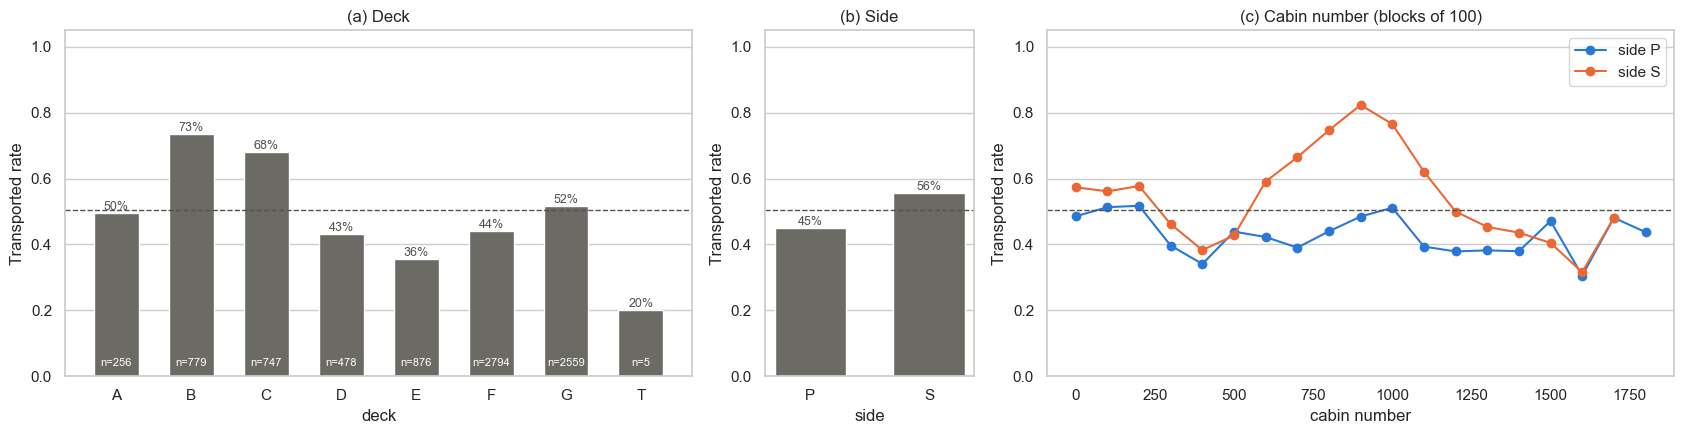

In [26]:
cabin = split_columns(train)
cabin["CabinNum"] = cabin["CabinNum"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [3, 1, 3]})
deck_rates = cabin.groupby("Deck")["Transported"].agg(["mean", "size"])
rate_bar(axes[0], deck_rates["mean"], "(a) Deck", "deck")
for i, n in enumerate(deck_rates["size"]):
    axes[0].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")
rate_bar(axes[1], cabin.groupby("Side")["Transported"].mean(), "(b) Side", "side")

# (c) Along the cabin number: blocks of 100 cabins, one line per side
ax = axes[2]
block = (cabin["CabinNum"] // 100 * 100).rename("block")
for side, color in [("P", "#2a78d6"), ("S", "#eb6834")]:
    rates = cabin[cabin["Side"] == side].groupby(block)["Transported"].mean()
    ax.plot(rates.index, rates.values, marker="o", color=color, label=f"side {side}")
ax.axhline(train["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
ax.set(ylim=(0, 1.05), title="(c) Cabin number (blocks of 100)", xlabel="cabin number", ylabel=RATE_LABEL)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Deck × side: are the two effects independent?
(cabin.pivot_table(index="Deck", columns="Side", values="Transported", aggfunc="mean") * 100).round(1)

Side,P,S
Deck,,
A,43.60,54.70
B,67.40,78.40
C,58.10,76.40
D,40.30,46.50
E,34.30,37.10
F,41.10,47.10
G,44.80,58.40
T,25.00,0.00


In [28]:
# Deck against CryoSleep: does the deck gap come from where the sleepers are?
cabin.groupby(["Deck", "CryoSleep"])["Transported"].mean().unstack().mul(100).round(1).assign(
    asleep_pct=cabin.groupby("Deck")["CryoSleep"].mean().mul(100).round(1)
)

CryoSleep,False,True,asleep_pct
Deck,,,
A,32.40,94.10,27.20
B,42.20,99.30,55.10
C,46.30,99.30,40.60
D,27.70,99.00,22.20
E,28.60,64.90,19.60
F,30.20,98.50,20.20
G,35.10,65.90,54.10
T,25.00,NaN,0.00


**Verdict: confirmed, location matters.**

- **Deck:** B (73%) and C (68%) are the most transported decks, E (36%) the least. Deck T holds only 5 passengers, so its rate means nothing.
- **Side:** starboard (S) 56%, port (P) 45%. The gap points the same way on almost every deck.
- **Cabin number:** on the starboard side, cabins 600–1100 reach 80%; there is no such peak to port. It looks as though the anomaly struck the starboard side, near the middle of the ship. The cabin number will have to be used as **regions**, not as a raw number.
- **The deck effect is not only about sleepers:** on decks B, C, D and F, 98–99% of the sleepers were transported, but only 65% on E and G. Awake passengers differ by deck too (D 28%, C 46%). So sleep and location are two separate, complementary clues.

### 2.3 Travelling together

**Intuition:** people in the same group (the first four digits of `PassengerId`) are usually family or friends: they share neighbouring cabins, they sleep or wander the ship together. They may have shared the same fate. The surname reaches beyond the group and marks kinship.

In [29]:
group = split_columns(train)
group["FamilySize"] = group["Surname"].map(full["Surname"].value_counts())  # passengers sharing the surname across train + test

# Group and surname counts never use the target: train + test are counted together
group["GroupSize"] = group["Group"].map(full["Group"].value_counts())
pd.Series({
    "groups (train + test)": full["Group"].nunique(),
    "travelling alone %": (full["GroupSize"] == 1).mean() * 100,
    "groups with members in both train and test": len(set(split_columns(train)["Group"]) & set(split_columns(test)["Group"])),
}, dtype=object)

groups (train + test)                         9280
travelling alone %                           55.09
groups with members in both train and test       0
dtype: object

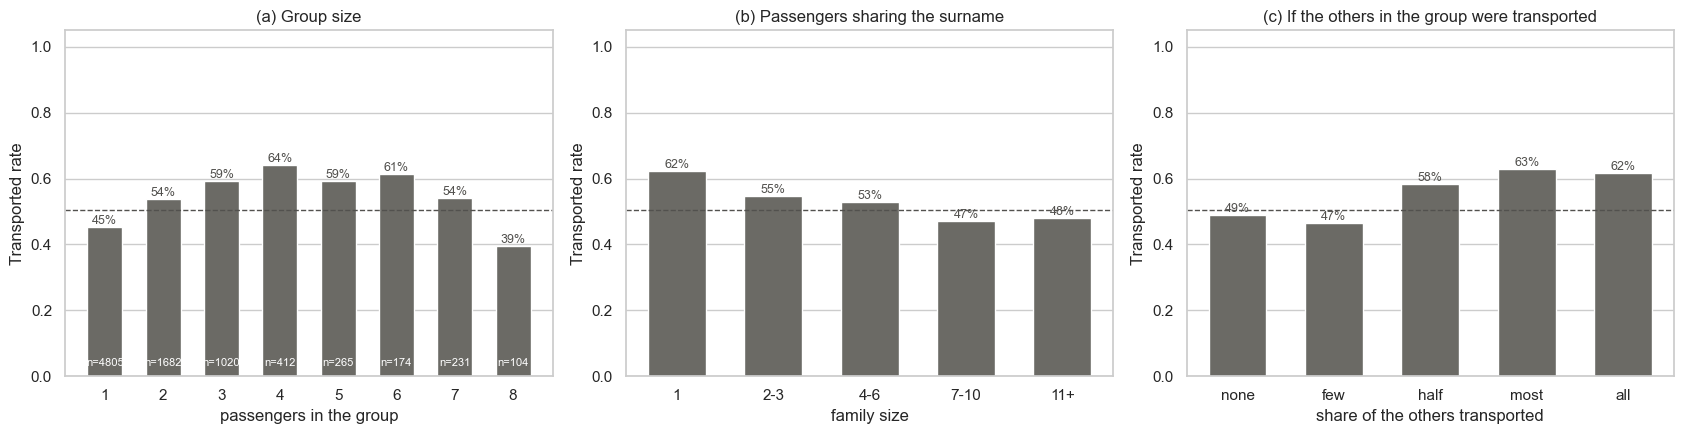

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

gs = group.groupby("GroupSize")["Transported"].agg(["mean", "size"])
rate_bar(axes[0], gs["mean"], "(a) Group size", "passengers in the group")
for i, n in enumerate(gs["size"]):
    axes[0].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")

fam_band = pd.cut(group["FamilySize"], [0, 1, 3, 6, 10, 20], labels=["1", "2-3", "4-6", "7-10", "11+"])
rate_bar(axes[1], group.groupby(fam_band, observed=True)["Transported"].mean(), "(b) Passengers sharing the surname", "family size")

# (c) Transported rate of the other group members → this passenger's rate
multi = group[group["GroupSize"] > 1].copy()
g_sum = multi.groupby("Group")["Transported"].transform("sum")
g_cnt = multi.groupby("Group")["Transported"].transform("count")
multi["others_rate"] = (g_sum - multi["Transported"]) / (g_cnt - 1)
others_band = pd.cut(multi["others_rate"], [-0.01, 0, 0.49, 0.51, 0.99, 1], labels=["none", "few", "half", "most", "all"])
rate_bar(axes[2], multi.groupby(others_band, observed=True)["Transported"].mean(), "(c) If the others in the group were transported", "share of the others transported")
plt.tight_layout()
plt.show()

In [31]:
# Do group members really share an outcome? Compare with random pairing
known = multi[g_cnt > 1]
same_outcome = known.groupby("Group")["Transported"].nunique().eq(1).mean() * 100

rng = np.random.default_rng(0)
shuffled = known.assign(Transported=rng.permutation(known["Transported"].values))
same_random = shuffled.groupby("Group")["Transported"].nunique().eq(1).mean() * 100

pd.Series({
    "groups with ≥2 members in train": known["Group"].nunique(),
    "groups where every member shared the outcome %": round(same_outcome, 1),
    "the same with randomly shuffled labels %": round(same_random, 1),
}, dtype=object)

groups with ≥2 members in train                   1412
groups where every member shared the outcome %   43.60
the same with randomly shuffled labels %         38.40
dtype: object

In [32]:
# What do group members share? Is that where the similarity comes from?
def share_pct(col):
    k = full[full["GroupSize"] > 1].dropna(subset=[col])
    k = k[k.groupby("Group")[col].transform("count") > 1]
    return k.groupby("Group")[col].nunique().eq(1).mean() * 100

pd.Series({col: share_pct(col) for col in ["HomePlanet", "Side", "Deck", "Cabin", "CryoSleep", "Destination"]},
          name="groups sharing one value %").round(1).to_frame()

,groups sharing one value %
HomePlanet,100.00
Side,100.00
Deck,67.50
Cabin,67.50
CryoSleep,40.70
Destination,48.50


**Verdict: partly confirmed. Being in a group matters, but the fate is not shared.**

- **Solo travellers were transported less often:** 45% against 57% for those in a group. The highest rate is in groups of four (64%). Groups of eight (39%, n=104) are the exception.
- **Family size is a weak clue:** in large families the rate drops to 47–48%. The 62% seen for unique surnames rests on only 133 passengers.
- **The "shared fate" hypothesis largely fails:** in 43.6% of the groups every member shared the same outcome. Shuffling the labels at random still gives 38.4%, so the gap is small. Even when everyone else in the group was transported, a passenger's own chance is only 62%.
- **Why:** group members share their home planet and their side of the ship 100% of the time, but share CryoSleep only 41% of the time. One member sleeps while another walks the ship, and it is that personal state that decides the outcome (2.1).
- **An important technical finding:** no group appears in both train and test. We can therefore never know the outcome of a test passenger's group mates. A feature like "were the others transported?" cannot be used on the test set, and would leak in cross-validation. Features that never touch the target — **group size and travelling alone** — are safe.

### 2.4 Where did they come from, where were they going?

**Intuition:** passengers come from three planets (Earth, Europa, Mars) and head for three destinations. Planets mean different lives on board: in 1.9 we saw Europans on the upper decks (A, B, C) and Earthlings on the lowest deck (G). Is the planet effect real, or only a reflection of deck and sleep?

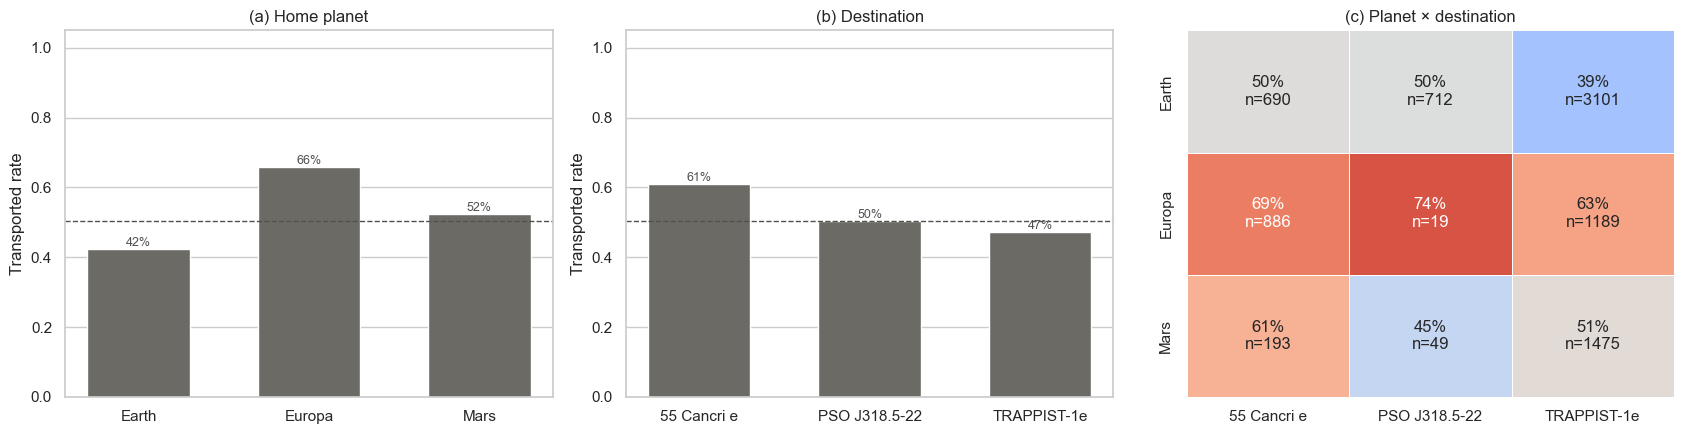

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
rate_bar(axes[0], train.groupby("HomePlanet", observed=True)["Transported"].mean(), "(a) Home planet", "")
rate_bar(axes[1], train.groupby("Destination", observed=True)["Transported"].mean(), "(b) Destination", "")

ax = axes[2]
pivot = train.pivot_table(index="HomePlanet", columns="Destination", values="Transported", aggfunc="mean", observed=True)
counts = train.pivot_table(index="HomePlanet", columns="Destination", values="Transported", aggfunc="size", observed=True)
sns.heatmap(pivot, annot=pivot.map("{:.0%}".format) + counts.map("\nn={}".format), fmt="", cmap="coolwarm",
            vmin=0.2, vmax=0.8, cbar=False, linewidths=0.5, ax=ax)
ax.grid(False)
ax.set(title="(c) Planet × destination", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

In [34]:
# Does the planet gap survive once the sleep state is held constant?
by_sleep = train.pivot_table(index="HomePlanet", columns="CryoSleep", values="Transported", aggfunc="mean", observed=True)
by_sleep.columns = ["awake", "asleep"]
(by_sleep * 100).round(1).assign(
    asleep_pct=(train.groupby("HomePlanet", observed=True)["CryoSleep"].mean() * 100).round(1),
    passengers=train["HomePlanet"].value_counts(),
)

,awake,asleep,asleep_pct,passengers
HomePlanet,,,,
Earth,32.10,65.60,30.80,4602
Europa,40.00,98.90,43.90,2131
Mars,27.70,91.20,39.00,1759


In [35]:
# Do passengers from different planets differ on the same deck? (decks D, E, F are mixed)
mixed = split_columns(train).query("Deck in ['D', 'E', 'F']")
pd.concat({
    "transported %": mixed.pivot_table(index="Deck", columns="HomePlanet", values="Transported", aggfunc="mean", observed=True) * 100,
    "passengers": mixed.pivot_table(index="Deck", columns="HomePlanet", values="Transported", aggfunc="size", observed=True),
}, axis=1).round(1)

transported %              passengers                
HomePlanet         Earth Europa  Mars      Earth Europa     Mars
Deck                                                            
D                    NaN  58.60 33.30        NaN 186.00   282.00
E                  37.20  54.70 26.10     395.00 128.00   330.00
F                  29.20    NaN 65.00   1,614.00    NaN 1,110.00

In [36]:
# VIP: few passengers, is there any link with being transported?
train.groupby("VIP")["Transported"].agg(transported_rate="mean", passengers="size")

,transported_rate,passengers
VIP,,
False,0.51,8291
True,0.38,199


**Verdict: confirmed. The planet is a clue of its own, but it is tangled with deck and sleep.**

- **Planet:** 66% of Europans, 52% of Martians and 42% of Earthlings were transported.
- **Holding sleep constant widens the gap:** 99% of sleeping Europans and 91% of sleeping Martians were transported, against only 66% of sleeping Earthlings. In 2.2 we said "sleepers on deck G were transported less often"; deck G is entirely Earthling. Two views of the same finding.
- **The planet matters within a deck too, but the direction changes with the deck:** on D and E, Europans (55–59%) were transported far more than Martians (26–33%); on F the Martians (65%) beat the Earthlings (29%). These **interactions** — an effect that changes with another variable — are where tree-based models shine.
- **Destination:** passengers bound for 55 Cancri e lead with 61%. Part of that comes from the many Europans heading there. The largest cell, Earth → TRAPPIST-1e (3101 passengers), is the lowest at 39%.
- **VIP:** VIPs 38%, everyone else 51%. There is a gap, but only 199 passengers are VIPs, so it is a weak clue. We keep the column and leave the decision to the model.

### 2.5 Age

**Intuition:** in 1.9 we saw that no child aged 0–12 spent anything. If children fared differently, does that come from age itself, or from not spending?

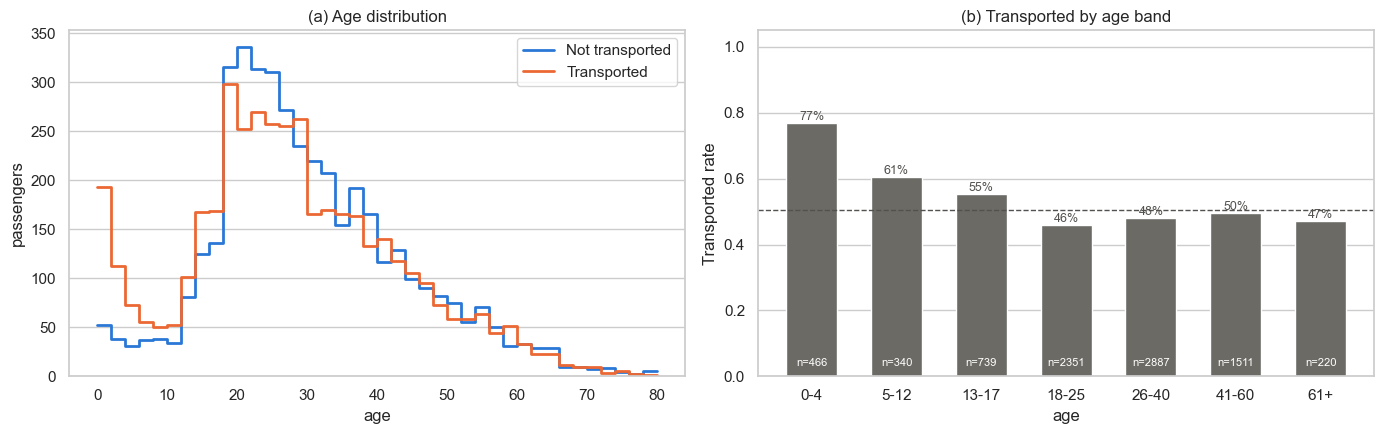

In [37]:
AGE_BINS = [-1, 4, 12, 17, 25, 40, 60, 80]
AGE_LABELS = ["0-4", "5-12", "13-17", "18-25", "26-40", "41-60", "61+"]
age_band = pd.cut(train["Age"], AGE_BINS, labels=AGE_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
for value in [False, True]:
    sns.histplot(train.loc[train["Transported"] == value, "Age"].dropna(), bins=range(0, 81, 2), element="step",
                 fill=False, linewidth=2, color=TARGET_COLORS[value], label=TARGET_LABELS[value], ax=ax)
ax.set(title="(a) Age distribution", xlabel="age", ylabel="passengers")
ax.legend()

ab = train.groupby(age_band, observed=True)["Transported"].agg(["mean", "size"])
rate_bar(axes[1], ab["mean"], "(b) Transported by age band", "age")
for i, n in enumerate(ab["size"]):
    axes[1].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")
plt.tight_layout()
plt.show()

In [38]:
# Compare with adults in the same state: is the child effect about age or about not spending?
state = pd.Series(
    np.select([train["CryoSleep"].fillna(False).astype(bool), train[SPEND_COLS].sum(axis=1) == 0],
              ["asleep", "awake, no spending"], "awake, spending"),
    index=train.index,
)
state[train["CryoSleep"].isna()] = np.nan
pd.concat({
    "transported %": train.pivot_table(index=age_band, columns=state, values="Transported", aggfunc="mean", observed=True) * 100,
    "passengers": train.pivot_table(index=age_band, columns=state, values="Transported", aggfunc="size", observed=True),
}, axis=1).round(1)

transported %                                    passengers  \
             asleep awake, no spending awake, spending     asleep   
Age                                                                 
0-4           78.10              76.20             NaN     237.00   
5-12          62.90              59.40             NaN     140.00   
13-17         84.80              20.00           25.60     356.00   
18-25         78.60              20.00           31.10     721.00   
26-40         85.50              38.80           29.00     941.00   
41-60         83.60              55.00           32.10     489.00   
61+           88.70             100.00           26.60      71.00   

                                          
      awake, no spending awake, spending  
Age                                       
0-4               214.00             NaN  
5-12              192.00             NaN  
13-17               5.00          356.00  
18-25              30.00        1,536.00  
26-40              49.00        1,832.00  
41-60              20.00          965.00  
61+                 1.00          143.00

**Verdict: confirmed, young children really are different.**

- 0–4 years 77%, 5–12 years 61%, 13–17 years 55%; among adults the rate stays flat at 46–50%. In the distribution chart the transported clearly outnumber the rest at ages 0–2.
- **The gap is not only about spending.** Among passengers who were awake and spent nothing: 0–4 years 76%, 18–25 years 20%, 26–40 years 39%. Compared with adults in the same state, small children were transported far more often.
- This also explains the "awake but no spending" group from 2.1 (62%): 406 of those 518 passengers are children under 13.
- Among sleepers, age barely matters (63–89%, with small children slightly lower).
- Among adults the effect of age is negligible. **An age band and a child flag** are enough; the raw number adds nothing.

### Chapter 2 summary: who was transported?

| Hypothesis | Verdict | Strength | What it means for the model |
|---|---|---|---|
| Sleep and spending | Confirmed: sleepers 82%, awake spenders 30% | Very strong | Split spending in two: luxury (RoomService, Spa, VRDeck) and basic (FoodCourt, ShoppingMall); log transform |
| Cabin location | Confirmed: decks B/C, starboard side, cabins 600–1100 to starboard | Strong | `Cabin` → `Deck`, `Side`, cabin region |
| Planet and destination | Confirmed, tangled with deck; interactions present | Medium | Tree-based models capture the interactions |
| Age | Confirmed: 77% at ages 0–4; awake children who spent nothing were transported far more than adults in the same state | Medium | Age band, child flag |
| Group and family | Partly: solo travellers are transported less, but the fate is not shared | Weak–medium | `GroupSize`, travelling alone; group outcomes must not be used |
| VIP | Weak gap, 199 passengers | Weak | Column stays, the model decides |

What decides the outcome is **what the passenger was doing** (sleep, spending) and **where they were** (deck, side, cabin region). Since groups are never split between train and test, cross-validation is built the same way (GroupKFold).

## Chapter 3: Preparing the Data for a Model

Three steps:

1. **Splitting columns:** breaking the packed columns into their parts.
2. **Rule-based filling:** filling the gaps with the relationships verified in 1.9. These rules never use the target (`Transported`), so they can be applied to train and test together.
3. **Pipeline:** filling what is left with statistics (median, most frequent value) and turning categories into numbers. Those statistics are learned **only from the training part of each CV fold**, never from the whole dataset, so nothing leaks from the validation data.

### 3.1 Splitting the columns

In [39]:
full = split_columns(pd.concat([train.drop(columns="Transported"), test], keys=["train", "test"]).reset_index(level=0).rename(columns={"level_0": "set"}).reset_index(drop=True))
full["CabinNum"] = full["CabinNum"].astype(float)
full[["PassengerId", "Group", "GroupSize", "Cabin", "Deck", "CabinNum", "Side", "Name", "Surname"]].head()

,PassengerId,Group,GroupSize,Cabin,Deck,CabinNum,Side,Name,Surname
0,0001_01,0001,1,B/0/P,B,0.00,P,Maham Ofracculy,Ofracculy
1,0002_01,0002,1,F/0/S,F,0.00,S,Juanna Vines,Vines
2,0003_01,0003,2,A/0/S,A,0.00,S,Altark Susent,Susent
3,0003_02,0003,2,A/0/S,A,0.00,S,Solam Susent,Susent
4,0004_01,0004,1,F/1/S,F,1.00,S,Willy Santantines,Santantines


### 3.2 Rule-based filling

The rules run in order, and a value filled by one rule can become the clue for the next (the surname is filled from the group first, then the planet from the surname).

| # | Column | Rule | Evidence |
|---|---|---|---|
| 1 | Spending | CryoSleep = True → 0 | None of the 4581 sleepers spent anything (1.9) |
| 2 | Spending | Age ≤ 12 → 0 | None of the 1157 children aged 0–12 spent anything (1.9) |
| 3 | CryoSleep | Any spending > 0 → False | The reverse of rule 1 |
| 4 | CryoSleep | No spending and age > 12 → True | 96% of non-spending passengers over 12 were asleep; for children that share is 48%, so the rule skips them |
| 5 | Surname | Most frequent surname in the group | 82% of the groups share one surname (1.9) |
| 6 | HomePlanet | The group's planet | 100% consistent (1.9) |
| 7 | HomePlanet | The surname's planet | 100% consistent (1.9) |
| 8 | HomePlanet | Deck A/B/C/T → Europa, G → Earth | 100% consistent (1.9) |
| 9 | Side | The group's side | 100% consistent (1.9) |
| 10 | Deck, CabinNum | Most frequent value in the group | 67% consistent; still better than the global mode |
| 11 | VIP | Earth → False | No VIP comes from Earth (1.9) |
| 12 | VIP | Age < 18 → False | Nobody under 18 is a VIP |

There is no reliable rule for `Destination` and `Age`; those gaps are filled inside the pipeline.

In [40]:
def mode_by(df, col, key):
    # the most frequent col value inside a key (e.g. Group), mapped back to every row
    known = df.dropna(subset=[col, key])
    modes = known.groupby(key)[col].agg(lambda s: s.mode().iloc[0])
    return df[key].map(modes)


def apply_rules(df):
    df = df.copy()
    log = []

    def fill(col, candidate, rule):
        mask = df[col].isna() & candidate.notna()
        df.loc[mask, col] = candidate[mask]
        log.append({"column": col, "rule": rule, "cells filled": int(mask.sum())})

    asleep = df["CryoSleep"].fillna(False).astype(bool)
    child = df["Age"] <= 12
    for col in SPEND_COLS:
        fill(col, pd.Series(np.where(asleep, 0.0, np.nan), index=df.index), "CryoSleep = True → 0")
    for col in SPEND_COLS:
        fill(col, pd.Series(np.where(child, 0.0, np.nan), index=df.index), "age ≤ 12 → 0")

    spent = df[SPEND_COLS].gt(0).any(axis=1)
    no_spend = df[SPEND_COLS].notna().all(axis=1) & (df[SPEND_COLS].sum(axis=1) == 0)
    fill("CryoSleep", pd.Series(np.where(spent, False, None), index=df.index), "spend > 0 → False")
    fill("CryoSleep", pd.Series(np.where(no_spend & (df["Age"] > 12), True, None), index=df.index), "no spending, age > 12 → True")

    fill("Surname", mode_by(df, "Surname", "Group"), "the group's surname")
    fill("HomePlanet", mode_by(df, "HomePlanet", "Group"), "the group's planet")
    fill("HomePlanet", mode_by(df, "HomePlanet", "Surname"), "the surname's planet")
    fill("HomePlanet", df["Deck"].map({"A": "Europa", "B": "Europa", "C": "Europa", "T": "Europa", "G": "Earth"}),
         "deck → planet")
    fill("Side", mode_by(df, "Side", "Group"), "the group's side")
    fill("Deck", mode_by(df, "Deck", "Group"), "the group's deck")
    fill("CabinNum", mode_by(df, "CabinNum", "Group"), "the group's cabin number")
    fill("VIP", pd.Series(np.where(df["HomePlanet"] == "Earth", False, None), index=df.index), "Earth → False")
    fill("VIP", pd.Series(np.where(df["Age"] < 18, False, None), index=df.index), "age < 18 → False")

    df["CryoSleep"] = df["CryoSleep"].astype("boolean")
    df["VIP"] = df["VIP"].astype("boolean")
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, min_count=1)
    return df, pd.DataFrame(log)


CHECK_COLS = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP"] + SPEND_COLS + ["Deck", "CabinNum", "Side", "Surname"]
before = full[CHECK_COLS].isna().sum()
full_filled, rule_log = apply_rules(full)
after = full_filled[CHECK_COLS].isna().sum()

rule_log.groupby(["column", "rule"], sort=False)["cells filled"].sum().to_frame()

,,cells filled
column,rule,
RoomService,CryoSleep = True → 0,93
FoodCourt,CryoSleep = True → 0,109
ShoppingMall,CryoSleep = True → 0,131
Spa,CryoSleep = True → 0,107
VRDeck,CryoSleep = True → 0,91
RoomService,age ≤ 12 → 0,8
FoodCourt,age ≤ 12 → 0,9
ShoppingMall,age ≤ 12 → 0,12
Spa,age ≤ 12 → 0,11


In [41]:
pd.DataFrame({
    "before": before,
    "after the rules": after,
    "filled by rules %": ((before - after) / before * 100).round(1),
})

,before,after the rules,filled by rules %
HomePlanet,288,10,96.50
CryoSleep,310,38,87.70
Destination,274,274,0.00
Age,270,270,0.00
VIP,296,123,58.40
RoomService,263,162,38.40
FoodCourt,289,171,40.80
ShoppingMall,306,163,46.70
Spa,284,166,41.50
VRDeck,268,150,44.00


In [42]:
# Check: did the rules leave any self-contradicting row behind?
pd.Series({
    "asleep yet spent": (full_filled["CryoSleep"].fillna(False).astype(bool) & (full_filled["TotalSpend"] > 0)).sum(),
    "under 13 yet spent": ((full_filled["Age"] <= 12) & (full_filled["TotalSpend"] > 0)).sum(),
    "VIP from Earth": ((full_filled["HomePlanet"] == "Earth") & full_filled["VIP"].fillna(False).astype(bool)).sum(),
    "non-Earth on deck G": ((full_filled["Deck"] == "G") & (full_filled["HomePlanet"].notna()) & (full_filled["HomePlanet"] != "Earth")).sum(),
})

asleep yet spent       0
under 13 yet spent     0
VIP from Earth         0
non-Earth on deck G    0
dtype: int64

**How accurate are the rules?** For passengers whose value is known we hide that value, let the rule predict it, and compare with the truth. In the group- and surname-based rules the passenger's own value is excluded; only the other members count.

In [43]:
def loo_mode(df, col, key):
    # For each passenger: the most frequent col value among the OTHER passengers in the same key
    known = df.dropna(subset=[col, key])
    counts = known.groupby([key, col], observed=True).size()
    out = pd.Series(np.nan, index=known.index, dtype=object)
    for idx, k, v in zip(known.index, known[key], known[col]):
        c = counts.loc[k].copy()
        c[v] -= 1
        c = c[c > 0]
        if len(c):
            out[idx] = c.idxmax()
    return out


def rule_check(name, actual, predicted):
    m = actual.notna() & predicted.notna()
    return {"rule": name, "passengers tested": int(m.sum()),
            "accuracy %": round((actual[m].astype(str) == predicted[m].astype(str)).mean() * 100, 2)}


asleep = full["CryoSleep"] == True
spend_known = full[SPEND_COLS].notna().all(axis=1)
no_spend = spend_known & (full["TotalSpend"] == 0)
checks = [
    rule_check("asleep → spend 0", (full.loc[asleep & spend_known, "TotalSpend"] == 0), pd.Series(True, index=full[asleep & spend_known].index)),
    rule_check("age ≤ 12 → spend 0", (full.loc[(full["Age"] <= 12) & spend_known, "TotalSpend"] == 0),
               pd.Series(True, index=full[(full["Age"] <= 12) & spend_known].index)),
    rule_check("spend > 0 → awake", full.loc[full["TotalSpend"] > 0, "CryoSleep"], pd.Series(False, index=full[full["TotalSpend"] > 0].index)),
    rule_check("no spending, age > 12 → asleep", full.loc[no_spend & (full["Age"] > 12), "CryoSleep"],
               pd.Series(True, index=full[no_spend & (full["Age"] > 12)].index)),
    rule_check("group → surname", full["Surname"], loo_mode(full, "Surname", "Group")),
    rule_check("group → planet", full["HomePlanet"], loo_mode(full, "HomePlanet", "Group")),
    rule_check("surname → planet", full["HomePlanet"], loo_mode(full, "HomePlanet", "Surname")),
    rule_check("deck → planet", full["HomePlanet"], full["Deck"].map({"A": "Europa", "B": "Europa", "C": "Europa", "T": "Europa", "G": "Earth"})),
    rule_check("group → side", full["Side"], loo_mode(full, "Side", "Group")),
    rule_check("group → deck", full["Deck"], loo_mode(full, "Deck", "Group")),
    rule_check("group → cabin number", full["CabinNum"], loo_mode(full, "CabinNum", "Group")),
    rule_check("Earth → not VIP", full.loc[full["HomePlanet"] == "Earth", "VIP"], pd.Series(False, index=full[full["HomePlanet"] == "Earth"].index)),
    rule_check("age < 18 → not VIP", full.loc[full["Age"] < 18, "VIP"], pd.Series(False, index=full[full["Age"] < 18].index)),
]
rule_acc = pd.DataFrame(checks).set_index("rule")

# For comparison: how accurate would simple filling (most frequent value) be on the same passengers?
simple_acc = {
    "group → planet": (full["HomePlanet"].dropna() == full["HomePlanet"].mode()[0]).mean() * 100,
    "surname → planet": (full["HomePlanet"].dropna() == full["HomePlanet"].mode()[0]).mean() * 100,
    "group → deck": (full["Deck"].dropna() == full["Deck"].mode()[0]).mean() * 100,
    "group → side": (full["Side"].dropna() == full["Side"].mode()[0]).mean() * 100,
    "no spending, age > 12 → asleep": (full["CryoSleep"].dropna() == full["CryoSleep"].mode()[0]).mean() * 100,
}
rule_acc["most-frequent filling %"] = pd.Series(simple_acc).round(2)
rule_acc

,passengers tested,accuracy %,most-frequent filling %
rule,,,
asleep → spend 0,4068,100.00,NaN
age ≤ 12 → spend 0,1030,100.00,NaN
spend > 0 → awake,7339,100.00,NaN
"no spending, age > 12 → asleep",3615,96.40,63.82
group → surname,5622,85.82,NaN
group → planet,5634,100.00,54.13
surname → planet,12183,100.00,54.13
deck → planet,6261,100.00,NaN
group → side,5620,100.00,50.36


### 3.3 The pipeline

What is left after the rules, and the transformations handed to the model:

| Column type | Columns | Filling | Transformation |
|---|---|---|---|
| Age | `Age` | Median by planet × spending state (1.9) | Scaling |
| Spending | the 5 amenities | Median (0) | `log(1 + x)`, scaling (skew 6–13) |
| Cabin number | `CabinNum` | Median | Scaling |
| Boolean | `CryoSleep`, `VIP` | Most frequent value | 0/1 |
| Categorical | `HomePlanet`, `Destination`, `Deck`, `Side` | Most frequent value | One-hot |

This step uses the original information only; the new features (spending groups, cabin region, group size) arrive in Chapter 4. That way the contribution of each step can be measured separately.

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class AgeImputer(BaseEstimator, TransformerMixin):
    # Fills a missing age with the planet × spending median learned from the training data
    def _key(self, X):
        return X["HomePlanet"].astype(str) + "_" + (X[SPEND_COLS].sum(axis=1) > 0).astype(str)

    def fit(self, X, y=None):
        self.medians_ = X.groupby(self._key(X))["Age"].median()
        self.global_median_ = X["Age"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = X["Age"].fillna(self._key(X).map(self.medians_)).fillna(self.global_median_)
        return X


BASE_NUM = ["Age", "CabinNum"]
BASE_BOOL = ["CryoSleep", "VIP"]
BASE_CAT = ["HomePlanet", "Destination", "Deck", "Side"]
BASE_FEATURES = BASE_NUM + SPEND_COLS + BASE_BOOL + BASE_CAT


BASE_SPEC = {"num": BASE_NUM, "log": SPEND_COLS, "bool": BASE_BOOL, "cat": BASE_CAT}


def to_model_frame(df, spec=BASE_SPEC):
    # turn boolean/category dtypes into the float/object sklearn understands
    cols = list(dict.fromkeys(sum(spec.values(), []) + ["HomePlanet"] + SPEND_COLS))  # needed by AgeImputer
    X = df[cols].copy()
    X[spec["bool"]] = X[spec["bool"]].astype("float")
    X[spec["cat"]] = X[spec["cat"]].astype("object").where(X[spec["cat"]].notna(), np.nan)
    return X


def make_preprocessor(spec=BASE_SPEC, age_imputer=True):
    columns = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), spec["num"]),
        ("log", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p), StandardScaler()), spec["log"]),
        ("bool", SimpleImputer(strategy="most_frequent"), spec["bool"]),
        ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), spec["cat"]),
    ])
    steps = [("age", AgeImputer())] if age_imputer else []
    return Pipeline(steps + [("columns", columns)])


is_train = full_filled["set"] == "train"
y = train["Transported"].astype(int).values
groups = full_filled.loc[is_train, "Group"].values
X_rules = to_model_frame(full_filled[is_train])
X_simple = to_model_frame(full[is_train])  # split columns only, no rules

prep = make_preprocessor().fit(X_rules)
Xt = prep.transform(X_rules)
print(f"Pipeline output: {Xt.shape[0]} rows × {Xt.shape[1]} columns, gaps left: {np.isnan(Xt).sum()}")

Pipeline output: 8693 rows × 25 columns, gaps left: 0


### 3.4 Does the pipeline work? A first measurement

We try the pipeline with two models: a linear one (Logistic Regression) and a tree-based one (HistGradientBoosting, default settings). Two questions:

- **Does rule-based filling help?** The same pipeline is run without the rules as well (median / most frequent value only).
- **How should CV be built?** In 2.3 no group was ever split between train and test. We compare a plain KFold with StratifiedGroupKFold, which keeps groups together.

Every measurement is 5-fold CV × 3 repeats = 15 scores.

In [45]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
}


def cv_scores(model, X, cv_kind="group", repeats=3):
    scores = []
    for seed in range(repeats):
        if cv_kind == "group":
            cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
            scores += list(cross_val_score(model, X, y, cv=cv, groups=groups, scoring="accuracy"))
        else:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
            scores += list(cross_val_score(model, X, y, cv=cv, scoring="accuracy"))
    return np.array(scores)


results = {}
for name, model in MODELS.items():
    for label, X in [("no rules", X_simple), ("with rules", X_rules)]:
        s = cv_scores(Pipeline([("prep", make_preprocessor()), ("model", model)]), X)
        results[(name, label)] = s

pd.DataFrame(
    {k: {"mean %": v.mean() * 100, "std %": v.std() * 100} for k, v in results.items()}
).T.round(2)

mean %  std %
Logistic Regression  no rules     77.82   0.94
                     with rules   77.81   0.84
HistGradientBoosting no rules     80.85   0.63
                     with rules   80.75   0.81

In [46]:
# CV flavour: does the score change when groups are split?
hgb = Pipeline([("prep", make_preprocessor()), ("model", HistGradientBoostingClassifier(random_state=0))])
cv_compare = {kind: cv_scores(hgb, X_rules, cv_kind=kind) for kind in ["plain", "group"]}
pd.DataFrame({
    "StratifiedKFold (groups may be split)": [cv_compare["plain"].mean() * 100, cv_compare["plain"].std() * 100],
    "StratifiedGroupKFold (groups kept together)": [cv_compare["group"].mean() * 100, cv_compare["group"].std() * 100],
}, index=["mean %", "std %"]).T.round(2)

,mean %,std %
StratifiedKFold (groups may be split),80.83,0.55
StratifiedGroupKFold (groups kept together),80.75,0.81


**Metrics beyond accuracy.** The competition scores accuracy, but the other metrics show which way the model errs:

- **Precision:** of the passengers we call "transported", how many really were?
- **Recall:** of those really transported, how many did we catch?
- **F1:** the balance of precision and recall.
- **ROC AUC:** how well does the model rank passengers by their probability of being transported? 0.5 is random, 1.0 is a perfect ranking.

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate, cross_val_predict

SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_rows = {}
for name, model in MODELS.items():
    for label, X in [("no rules", X_simple), ("with rules", X_rules)]:
        pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
        per_seed = [cross_validate(pipe, X, y, groups=groups, scoring=SCORING,
                                   cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed))
                    for seed in range(3)]
        metric_rows[(name, label)] = {
            m: f"{np.mean(np.concatenate([r[f'test_{m}'] for r in per_seed])):.4f} ± {np.std(np.concatenate([r[f'test_{m}'] for r in per_seed])):.4f}"
            for m in SCORING
        }
pd.DataFrame(metric_rows).T

accuracy        precision  \
Logistic Regression  no rules    0.7782 ± 0.0094  0.7720 ± 0.0137   
                     with rules  0.7781 ± 0.0084  0.7721 ± 0.0133   
HistGradientBoosting no rules    0.8085 ± 0.0063  0.8095 ± 0.0124   
                     with rules  0.8075 ± 0.0081  0.8083 ± 0.0142   

                                          recall               f1  \
Logistic Regression  no rules    0.7943 ± 0.0115  0.7829 ± 0.0091   
                     with rules  0.7935 ± 0.0117  0.7826 ± 0.0084   
HistGradientBoosting no rules    0.8104 ± 0.0113  0.8098 ± 0.0082   
                     with rules  0.8096 ± 0.0121  0.8089 ± 0.0102   

                                         roc_auc  
Logistic Regression  no rules    0.8521 ± 0.0069  
                     with rules  0.8530 ± 0.0067  
HistGradientBoosting no rules    0.9003 ± 0.0064  
                     with rules  0.9022 ± 0.0054

In [48]:
# Confusion matrix: HistGradientBoosting, with rules, every passenger validated once
pred = cross_val_predict(Pipeline([("prep", make_preprocessor()), ("model", HistGradientBoostingClassifier(random_state=0))]),
                         X_rules, y, groups=groups, cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0))
cm = pd.DataFrame(confusion_matrix(y, pred), index=["actual: not transported", "actual: transported"],
                  columns=["predicted: not transported", "predicted: transported"])
cm

,predicted: not transported,predicted: transported
actual: not transported,3480,835
actual: transported,856,3522


**Verdict**

- **The pipeline works:** 8693 rows × 25 columns, no missing values left. The rules left no self-contradicting row behind.
- **The rules filled most of the gaps:** 97% of the missing `HomePlanet` values and 88% of the missing `CryoSleep` values. For spending, cabin and surname the share is 40–47%.
- **But the CV score did not move:** the gap between rules and no rules is under 0.1 points, well inside the standard deviation of the scores (0.6–0.9). Two reasons:
  - Only 2% of each column is missing. In train the rules touch just 100–200 cells per column, which can only affect a handful of predictions.
  - The median of the spending columns is already 0, so "a sleeper spent nothing" gives the same value as median filling on most rows.
- **The tree-based model is 3 points ahead of the linear one** (80.8% against 77.8%), which matches the interactions seen in 2.4.
- **The CV flavour made no difference either** (80.83% against 80.75%). Splitting groups does not inflate the score yet. Since group-based features arrive in Chapter 4 and raise the leakage risk, we continue with StratifiedGroupKFold, which keeps groups together.

## Chapter 4: From Findings to Features

Every finding from Chapter 2 becomes a column the model can use:

| Feature set | New columns | Finding behind it |
|---|---|---|
| Spending groups | `LuxurySpend` (RoomService + Spa + VRDeck), `BasicSpend` (FoodCourt + ShoppingMall), `TotalSpend`, `NoSpend` | 2.1: more luxury spending, less transported; U shape for basic spending |
| Cabin region | `CabinRegion` (cabin number in blocks of 300) | 2.2: the 600–1100 region on the starboard side |
| Group | `GroupSize`, `IsSolo` | 2.3: solo travellers 45%, group travellers 57% |
| Family | `FamilySize` (passengers sharing the surname) | 2.3: lower rate in large families |
| Age | `IsChild` (≤ 12), `AgeGroup` | 2.5: 77% at ages 0–4 |

Group and family sizes are counted over train and test together, without touching the target.

In [49]:
def add_features(df):
    df = df.copy()
    df["LuxurySpend"] = df[["RoomService", "Spa", "VRDeck"]].sum(axis=1)
    df["BasicSpend"] = df[["FoodCourt", "ShoppingMall"]].sum(axis=1)
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1)
    df["NoSpend"] = (df["TotalSpend"] == 0).astype(float)
    df["CabinRegion"] = (df["CabinNum"] // 300).astype("Int64").astype(str).replace("<NA>", np.nan)
    df["IsSolo"] = (df["GroupSize"] == 1).astype(float)
    df["FamilySize"] = df["Surname"].map(df["Surname"].value_counts())
    df["IsChild"] = (df["Age"] <= 12).astype(float).where(df["Age"].notna())
    df["AgeGroup"] = pd.cut(df["Age"], AGE_BINS, labels=AGE_LABELS).astype(object)
    # the region found in 7.4: lower decks (F, G), starboard side, cabins 600–1199
    df["HotZone"] = (df["Deck"].isin(["F", "G"]) & (df["Side"] == "S") & df["CabinNum"].between(600, 1199)).astype(float)
    df.loc[df["CabinNum"].isna() | df["Side"].isna() | df["Deck"].isna(), "HotZone"] = np.nan
    return df


fe = add_features(full_filled)
X_fe_all = fe[is_train]

FEATURE_SETS = {
    "spending groups": {"log": ["LuxurySpend", "BasicSpend", "TotalSpend"], "bool": ["NoSpend"]},
    "cabin region": {"cat": ["CabinRegion"]},
    "group": {"num": ["GroupSize"], "bool": ["IsSolo"]},
    "family": {"num": ["FamilySize"]},
    "age": {"bool": ["IsChild"], "cat": ["AgeGroup"]},
}


def extend(spec, *extras):
    out = {k: list(v) for k, v in spec.items()}
    for extra in extras:
        for k, v in extra.items():
            out[k] = out[k] + v
    return out


fe[is_train][["LuxurySpend", "BasicSpend", "TotalSpend", "NoSpend", "CabinRegion", "GroupSize", "IsSolo",
              "FamilySize", "IsChild", "AgeGroup"]].head()

,LuxurySpend,BasicSpend,TotalSpend,NoSpend,CabinRegion,GroupSize,IsSolo,FamilySize,IsChild,AgeGroup
0,0.00,0.00,0.00,1.00,0,1,1.00,4.00,0.00,26-40
1,702.00,34.00,736.00,0.00,0,1,1.00,4.00,0.00,18-25
2,"6,807.00","3,576.00","10,383.00",0.00,0,2,0.00,7.00,0.00,41-60
3,"3,522.00","1,654.00","5,176.00",0.00,0,2,0.00,7.00,0.00,26-40
4,870.00,221.00,"1,091.00",0.00,0,1,1.00,9.00,0.00,13-17


### 4.1 What does each feature set add?

Each set is added to the base model **on its own**, and then **all of them together**. Every experiment uses the same 15 CV splits, so the differences are paired and comparable.

Whether a difference is real or noise is checked with the **corrected paired t-test** (Nadeau and Bengio, 2003). CV splits overlap, which makes an ordinary t-test call differences more significant than they are; this test accounts for the overlap. p < 0.05 means the difference is probably real.

In [50]:
from scipy import stats

N_SPLITS, N_REPEATS = 5, 3
SPLITS = [split for seed in range(N_REPEATS)
          for split in StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(X_fe_all, y, groups)]


def evaluate(model, spec):
    X = to_model_frame(X_fe_all, spec)
    pipe = Pipeline([("prep", make_preprocessor(spec)), ("model", model)])
    r = cross_validate(pipe, X, y, cv=SPLITS, scoring=["accuracy", "f1", "roc_auc"])
    return {m: r[f"test_{m}"] for m in ["accuracy", "f1", "roc_auc"]}


def corrected_ttest(a, b):
    # Nadeau & Bengio correction: add variance for the test / train ratio
    d = b - a
    ratio = 1 / (N_SPLITS - 1)
    t = d.mean() / np.sqrt((1 / len(d) + ratio) * d.var(ddof=1))
    return 2 * stats.t.sf(abs(t), df=len(d) - 1)


def run_ablation(model):
    runs = {"base": evaluate(model, BASE_SPEC)}
    for name, extra in FEATURE_SETS.items():
        runs[f"+ {name}"] = evaluate(model, extend(BASE_SPEC, extra))
    runs["+ all"] = evaluate(model, extend(BASE_SPEC, *FEATURE_SETS.values()))
    base = runs["base"]["accuracy"]
    return pd.DataFrame({
        name: {
            "accuracy %": r["accuracy"].mean() * 100,
            "± std": r["accuracy"].std() * 100,
            "F1 %": r["f1"].mean() * 100,
            "ROC AUC %": r["roc_auc"].mean() * 100,
            "gain (points)": (r["accuracy"].mean() - base.mean()) * 100,
            "p": np.nan if name == "base" else corrected_ttest(base, r["accuracy"]),
        }
        for name, r in runs.items()
    }).T.round({"accuracy %": 2, "± std": 2, "F1 %": 2, "ROC AUC %": 2, "gain (points)": 2, "p": 3}), runs


hgb_table, hgb_runs = run_ablation(HistGradientBoostingClassifier(random_state=0))
hgb_table

,accuracy %,± std,F1 %,ROC AUC %,gain (points),p
base,80.75,0.81,80.89,90.22,0.00,NaN
+ spending groups,81.26,0.81,81.41,90.49,0.51,0.07
+ cabin region,80.87,0.64,80.99,90.14,0.12,0.68
+ group,81.03,0.77,81.16,90.17,0.28,0.33
+ family,80.99,0.76,81.11,90.16,0.24,0.43
+ age,81.11,0.81,81.21,90.26,0.36,0.22
+ all,81.14,0.64,81.25,90.51,0.39,0.21


In [51]:
lr_table, lr_runs = run_ablation(LogisticRegression(max_iter=3000))
lr_table

,accuracy %,± std,F1 %,ROC AUC %,gain (points),p
base,77.81,0.84,78.26,85.30,0.00,NaN
+ spending groups,79.61,0.83,80.04,86.17,1.80,0.00
+ cabin region,77.86,0.80,78.32,85.83,0.05,0.86
+ group,77.73,0.89,78.19,85.31,-0.08,0.53
+ family,77.80,0.84,78.26,85.29,-0.00,0.90
+ age,77.78,0.84,78.22,85.39,-0.02,0.88
+ all,79.89,0.91,80.29,86.87,2.08,0.00


**Verdict**

- **In HistGradientBoosting every feature set lifts the score a little, but none of them is statistically significant.** The largest gain comes from the spending groups: +0.51 points, p = 0.07, right at the edge of significance. The rest add between +0.1 and +0.4 points, indistinguishable from noise.
- **Adding everything is no better than adding the spending groups alone** (81.14 against 81.26). The tree model already extracts most of this from the raw columns: it splits `CabinNum` at its own thresholds and recognises children from age and from the absence of spending.
- **The picture differs for Logistic Regression:** the spending groups are worth +1.8 points and the difference is clearly significant (p < 0.001). A linear model cannot build "luxury spending lowers the chance of being transported" out of the individual amenities; it has to be handed the sum. The other sets add nothing there either.
- **The cabin region failed in both models.** The peak in 2.2 only existed on the starboard side; adding the region without the side does not carry that interaction.
- **The lesson of this step:** a strong finding in the exploratory analysis does not always reach the model as *new* information. The model may already have learned it from the raw columns. That is why every feature has to be measured.

### 4.2 A first submission

The best model so far (HistGradientBoosting + spending groups) is trained on the whole training set and predicts the test passengers. The point is to see early how well the CV score agrees with the Kaggle leaderboard.

In [52]:
SUBMISSION_DIR = Path("submissions")
SUBMISSION_DIR.mkdir(exist_ok=True)
X_fe_test = fe[~is_train]


def make_submission(models, spec, filename):
    # A single model or a list of models (probabilities are averaged over a list)
    models = models if isinstance(models, list) else [models]
    proba = np.mean([
        Pipeline([("prep", make_preprocessor(spec)), ("model", m)])
        .fit(to_model_frame(X_fe_all, spec), y)
        .predict_proba(to_model_frame(X_fe_test, spec))[:, 1]
        for m in models
    ], axis=0)
    pred = proba >= 0.5
    submission = pd.DataFrame({"PassengerId": X_fe_test["PassengerId"].values, "Transported": pred})
    path = SUBMISSION_DIR / filename
    submission.to_csv(path, index=False)

    # Compare with the format Kaggle expects
    sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
    saved = pd.read_csv(path)
    checks = pd.Series({
        "rows (4277 expected)": len(saved),
        "columns match the sample file": list(saved.columns) == list(sample.columns),
        "PassengerId order matches the sample file": saved["PassengerId"].equals(sample["PassengerId"]),
        "values are True/False": set(saved["Transported"].unique()) <= {True, False},
        "missing values": int(saved.isna().sum().sum()),
        "predicted transported %": round(saved["Transported"].mean() * 100, 1),
    }, dtype=object)
    return path, checks


SPEC_SPEND = extend(BASE_SPEC, FEATURE_SETS["spending groups"])
path, checks = make_submission(HistGradientBoostingClassifier(random_state=0), SPEC_SPEND, "01_hgb_spend_groups.csv")
print(path)
checks

submissions/01_hgb_spend_groups.csv


rows (4277 expected)                         4277
columns match the sample file                True
PassengerId order matches the sample file    True
values are True/False                        True
missing values                                  0
predicted transported %                     51.90
dtype: object

**Kaggle public score: 0.80219** (CV: 0.8126 ± 0.0081).

The gap is about 1 point. The public leaderboard is computed on part of the test set only (roughly 2100 passengers), and at that sample size accuracy carries an uncertainty of about ±0.9 points on its own. So the gap sits at the edge of noise: CV may be mildly optimistic, but it agrees with the leaderboard. We keep making decisions on CV.

## Chapter 5: The Models Compete

Six models, the same features (base columns + all the new ones) and the same 15 CV splits. All of them run at or near their defaults; tuning is Chapter 6's job.

| Model | Type |
|---|---|
| Logistic Regression | Linear |
| Random Forest | Tree ensemble (bagging) |
| HistGradientBoosting | Gradient boosting (scikit-learn) |
| XGBoost | Gradient boosting |
| LightGBM | Gradient boosting |
| CatBoost | Gradient boosting |

In [53]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SPEC_ALL = extend(BASE_SPEC, *FEATURE_SETS.values())
CANDIDATES = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, n_jobs=-1, random_state=0),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=0),
    "CatBoost": CatBoostClassifier(iterations=1000, verbose=0, random_seed=0, thread_count=-1),
}

model_runs = {name: evaluate(model, SPEC_ALL) for name, model in CANDIDATES.items()}
best_name = max(model_runs, key=lambda n: model_runs[n]["accuracy"].mean())
best_acc = model_runs[best_name]["accuracy"]

model_table = pd.DataFrame({
    name: {
        "accuracy %": r["accuracy"].mean() * 100,
        "± std": r["accuracy"].std() * 100,
        "F1 %": r["f1"].mean() * 100,
        "ROC AUC %": r["roc_auc"].mean() * 100,
        f"{best_name} difference": (r["accuracy"].mean() - best_acc.mean()) * 100,
        "p": np.nan if name == best_name else corrected_ttest(r["accuracy"], best_acc),
    }
    for name, r in model_runs.items()
}).T.sort_values("accuracy %", ascending=False).round(3)
model_table

,accuracy %,± std,F1 %,ROC AUC %,CatBoost difference,p
CatBoost,81.53,0.90,81.77,90.84,0.00,NaN
LightGBM,81.23,0.69,81.20,90.47,-0.30,0.33
HistGradientBoosting,81.14,0.64,81.25,90.51,-0.38,0.26
XGBoost,81.07,0.52,81.21,90.50,-0.45,0.17
Random Forest,80.69,0.62,80.63,89.90,-0.83,0.09
Logistic Regression,79.89,0.91,80.29,86.86,-1.64,0.00


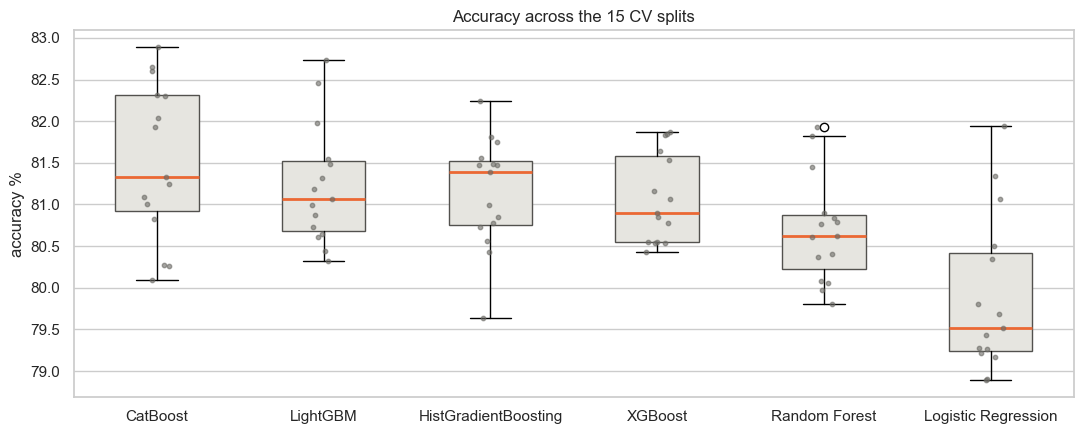

In [54]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = model_table.index.tolist()
ax.boxplot([model_runs[n]["accuracy"] * 100 for n in order], tick_labels=order, vert=True, patch_artist=True,
           boxprops={"facecolor": "#e6e5e0", "color": INK}, medianprops={"color": "#eb6834", "linewidth": 2})
for i, n in enumerate(order, start=1):
    ax.scatter(np.full(15, i) + np.random.default_rng(i).uniform(-0.08, 0.08, 15), model_runs[n]["accuracy"] * 100,
               s=10, color=NEUTRAL, alpha=0.6, zorder=3)
ax.set(title="Accuracy across the 15 CV splits", ylabel="accuracy %")
plt.tight_layout()
plt.show()

In [55]:
# How much do the models agree? Share of identical predictions (one CV repeat)
oof = {}
for name, model in CANDIDATES.items():
    pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", model)])
    oof[name] = cross_val_predict(pipe, to_model_frame(X_fe_all, SPEC_ALL), y, cv=SPLITS[:N_SPLITS])
oof = pd.DataFrame(oof)
agreement = pd.DataFrame({a: {b: (oof[a] == oof[b]).mean() * 100 for b in oof} for a in oof}).round(1)
agreement

,Logistic Regression,Random Forest,HistGradientBoosting,XGBoost,LightGBM,CatBoost
Logistic Regression,100.00,89.60,89.20,89.20,88.20,89.80
Random Forest,89.60,100.00,92.80,93.20,92.80,93.70
HistGradientBoosting,89.20,92.80,100.00,94.90,95.20,94.40
XGBoost,89.20,93.20,94.90,100.00,94.50,95.00
LightGBM,88.20,92.80,95.20,94.50,100.00,94.20
CatBoost,89.80,93.70,94.40,95.00,94.20,100.00


**Verdict**

- **The four gradient boosting models are neck and neck.** CatBoost leads with 81.53%, with LightGBM, HistGB and XGBoost 0.3–0.45 points behind. None of the differences is significant (p = 0.17–0.33), and in the chart the boxes overlap heavily.
- **Random Forest trails slightly** (−0.83 points, p = 0.09). **Logistic Regression clearly trails** (−1.64 points, p < 0.001); a linear model cannot capture the interactions here.
- **CatBoost is the most volatile** (± 0.90). Its best split is 82.9%, its worst 80.1%.
- **The models agree on 94–95% of the passengers.** They err on different passengers, which suggests an ensemble (averaging the predictions) might add a little. Logistic Regression is the model that thinks most differently (88–90% agreement).
- There is no single winner here, so all four boosting models go forward into tuning and ensembling.

## Chapter 6: Tuning and Blending

### 6.1 Tuning (Optuna)

Optuna searches the settings of the four gradient boosting models. Each trial picks a set of hyperparameters, measures it with CV, and uses the earlier trials to pick the next set more sensibly (the TPE method).

**A guard against overfitting:** try enough settings and one of them will look good by luck alone. To avoid that:

- the search runs on **a separate CV split** (seed 42, 5 folds);
- the winning settings are reported on the **15 splits** from Chapter 5, paired against the default settings.

Both splits come from the same data, so this is not a full nested CV; the reported gain may be mildly optimistic. The leaderboard will check it.

The search is slow (~10 minutes per model). Results are written to `tuning/` and read back on later runs of the notebook.

In [56]:
import json
import time

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
TUNING_DIR = Path("tuning")
TUNING_DIR.mkdir(exist_ok=True)
PARAMS_PATH = TUNING_DIR / "best_params.json"
TUNE_SPLITS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_fe_all, y, groups))
X_all_frame = to_model_frame(X_fe_all, SPEC_ALL)


def search_space(name, trial):
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            num_leaves=trial.suggest_int("num_leaves", 8, 128, log=True),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 100, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0), subsample_freq=1,
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            verbose=-1, random_state=0,
        )
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            min_child_weight=trial.suggest_float("min_child_weight", 1, 20, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            gamma=trial.suggest_float("gamma", 0, 5),
            n_jobs=-1, random_state=0,
        )
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int("max_iter", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 8, 64, log=True),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100, log=True),
            l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10, log=True),
            max_features=trial.suggest_float("max_features", 0.3, 1.0),
            random_state=0,
        )
    if name == "CatBoost":
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 300, 1500, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            depth=trial.suggest_int("depth", 3, 8),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 20, log=True),
            random_strength=trial.suggest_float("random_strength", 0, 5),
            bagging_temperature=trial.suggest_float("bagging_temperature", 0, 1),
            verbose=0, random_seed=0, thread_count=-1,
        )


def build_model(name, params):
    return search_space(name, optuna.trial.FixedTrial(params))


TUNED_NAMES = ["CatBoost", "LightGBM", "XGBoost", "HistGradientBoosting"]
DEFAULT_PARAMS = {  # the settings from Chapter 5 (rounded into the search range)
    "LightGBM": {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 20,
                 "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 0.001},
    "XGBoost": {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5, "min_child_weight": 1,
                "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "gamma": 0.0},
    "HistGradientBoosting": {"max_iter": 100, "learning_rate": 0.1, "max_leaf_nodes": 31, "min_samples_leaf": 20,
                             "l2_regularization": 0.001, "max_features": 1.0},
    "CatBoost": {"iterations": 1000, "learning_rate": 0.03, "depth": 6, "l2_leaf_reg": 3,
                 "random_strength": 1.0, "bagging_temperature": 1.0},
}
TIME_BUDGET = {"CatBoost": 900, "LightGBM": 600, "XGBoost": 600, "HistGradientBoosting": 600}

if PARAMS_PATH.exists():
    tuning = json.loads(PARAMS_PATH.read_text())
else:
    tuning = {}
    for name in TUNED_NAMES:
        def objective(trial):
            pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", search_space(name, trial))])
            return cross_val_score(pipe, X_all_frame, y, cv=TUNE_SPLITS, scoring="accuracy").mean()

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
        study.enqueue_trial(DEFAULT_PARAMS[name])  # first trial is the Chapter 5 setting: the search cannot go backwards from it
        start = time.time()
        study.optimize(objective, n_trials=200, timeout=TIME_BUDGET[name])
        study.trials_dataframe().to_csv(TUNING_DIR / f"trials_{name}.csv", index=False)
        tuning[name] = {"params": study.best_params, "tune_cv": study.best_value,
                        "trials": len(study.trials), "minutes": round((time.time() - start) / 60, 1)}
    PARAMS_PATH.write_text(json.dumps(tuning, indent=2))

pd.DataFrame({n: {"trials": t["trials"], "minutes": t["minutes"], "search CV %": t["tune_cv"] * 100}
              for n, t in tuning.items()}).T.round(2)

,trials,minutes,search CV %
CatBoost,50.00,15.10,81.78
LightGBM,53.00,11.70,81.37
XGBoost,200.00,9.60,81.55
HistGradientBoosting,28.00,10.20,81.60


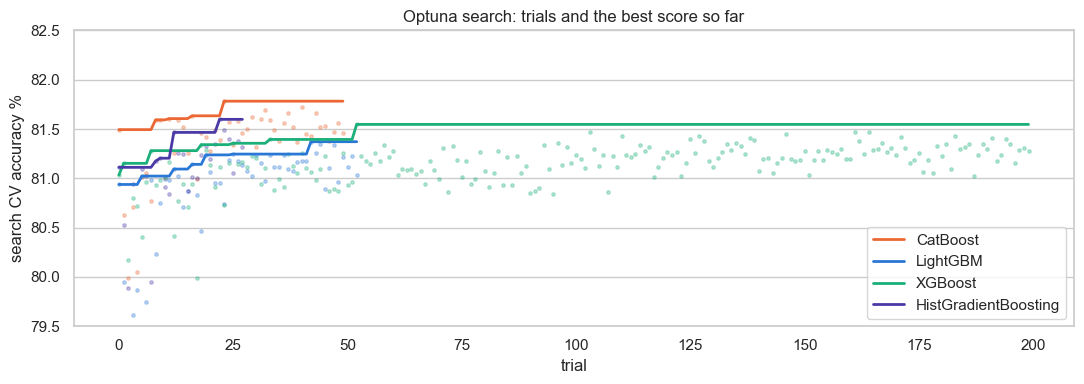

In [57]:
# How did the best score move as the search went on?
fig, ax = plt.subplots(figsize=(11, 4))
palette = {"CatBoost": "#eb6834", "LightGBM": "#2a78d6", "XGBoost": "#1baf7a", "HistGradientBoosting": "#4a3aa7"}
for name in TUNED_NAMES:
    trials = pd.read_csv(TUNING_DIR / f"trials_{name}.csv").query("state == 'COMPLETE'")
    ax.plot(trials["number"], trials["value"].cummax() * 100, color=palette[name], label=name, linewidth=2)
    ax.scatter(trials["number"], trials["value"] * 100, color=palette[name], s=6, alpha=0.3)
ax.set(title="Optuna search: trials and the best score so far", xlabel="trial", ylabel="search CV accuracy %",
       ylim=(79.5, 82.5))
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
for name in TUNED_NAMES:
    print(name, {k: round(v, 4) if isinstance(v, float) else v for k, v in tuning[name]["params"].items()})

CatBoost {'iterations': 1500, 'learning_rate': 0.0173, 'depth': 6, 'l2_leaf_reg': 9.9004, 'random_strength': 0.6985, 'bagging_temperature': 0.2164}
LightGBM {'n_estimators': 650, 'learning_rate': 0.0392, 'num_leaves': 9, 'min_child_samples': 15, 'subsample': 0.9052, 'colsample_bytree': 0.6978, 'reg_lambda': 0.0062}
XGBoost {'n_estimators': 450, 'learning_rate': 0.0231, 'max_depth': 5, 'min_child_weight': 3.112, 'subsample': 0.9926, 'colsample_bytree': 0.603, 'reg_lambda': 0.0186, 'gamma': 2.0913}
HistGradientBoosting {'max_iter': 350, 'learning_rate': 0.0173, 'max_leaf_nodes': 27, 'min_samples_leaf': 9, 'l2_regularization': 0.1083, 'max_features': 0.3447}


### 6.2 The tuned models on the 15 splits

In every split the models are trained and the **probability of being transported** is stored for the validation passengers. Those probabilities serve both to score the individual models and to try the blends in 6.3.

In [59]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


def split_probas(model, spec=SPEC_ALL):
    X = to_model_frame(X_fe_all, spec)
    out = []
    for tr, va in SPLITS:
        pipe = Pipeline([("prep", make_preprocessor(spec)), ("model", clone(model))]).fit(X.iloc[tr], y[tr])
        out.append(pipe.predict_proba(X.iloc[va])[:, 1])
    return out


def score_probas(probas, threshold=0.5):
    acc = np.array([accuracy_score(y[va], p >= threshold) for (tr, va), p in zip(SPLITS, probas)])
    f1 = np.array([f1_score(y[va], p >= threshold) for (tr, va), p in zip(SPLITS, probas)])
    auc = np.array([roc_auc_score(y[va], p) for (tr, va), p in zip(SPLITS, probas)])
    return {"accuracy": acc, "f1": f1, "roc_auc": auc}


import pickle

PROBAS_PATH = TUNING_DIR / "split_probas.pkl"  # takes ~15 minutes: computed once and cached
PROBA_KEYS = [f"{n} (tuned)" for n in TUNED_NAMES] + ["Logistic Regression"]
if PROBAS_PATH.exists():
    # one list of validation probabilities per model, stored in PROBA_KEYS order
    probas = dict(zip(PROBA_KEYS, pickle.loads(PROBAS_PATH.read_bytes()).values()))
else:
    probas = {f"{n} (tuned)": split_probas(build_model(n, tuning[n]["params"])) for n in TUNED_NAMES}
    probas["Logistic Regression"] = split_probas(LogisticRegression(max_iter=3000))
    PROBAS_PATH.write_bytes(pickle.dumps(probas))
tuned_runs = {n: score_probas(p) for n, p in probas.items()}


def summary_table(runs, reference):
    ref = runs[reference]["accuracy"] if reference in runs else reference
    return pd.DataFrame({
        n: {
            "accuracy %": r["accuracy"].mean() * 100, "± std": r["accuracy"].std() * 100,
            "F1 %": r["f1"].mean() * 100, "ROC AUC %": r["roc_auc"].mean() * 100,
        }
        for n, r in runs.items()
    }).T


rows = []
for n in TUNED_NAMES:
    default, tuned = model_runs[n]["accuracy"], tuned_runs[f"{n} (tuned)"]["accuracy"]
    rows.append({"model": n, "default %": default.mean() * 100, "tuned %": tuned.mean() * 100,
                 "gain (points)": (tuned.mean() - default.mean()) * 100, "p": corrected_ttest(default, tuned),
                 "tuned F1 %": tuned_runs[f"{n} (tuned)"]["f1"].mean() * 100,
                 "tuned ROC AUC %": tuned_runs[f"{n} (tuned)"]["roc_auc"].mean() * 100})
pd.DataFrame(rows).set_index("model").round(3)

,default %,tuned %,gain (points),p,tuned F1 %,tuned ROC AUC %
model,,,,,,
CatBoost,81.53,81.59,0.06,0.78,81.85,90.83
LightGBM,81.23,81.32,0.09,0.73,81.58,90.68
XGBoost,81.07,81.16,0.09,0.77,81.55,90.49
HistGradientBoosting,81.14,81.31,0.17,0.66,81.68,90.65


### 6.3 Blending (ensemble)

In Chapter 5 the models disagreed on 5–6% of the passengers. Averaging the probabilities lets one model's mistake be corrected by the others. The blends tried here:

- **4 boosting:** the probability average of the four tuned models
- **CatBoost + LightGBM:** the best two models
- **4 boosting + LR:** adding the model that thinks most differently

In [60]:
def blend(names, weights=None):
    weights = np.ones(len(names)) if weights is None else np.asarray(weights, dtype=float)
    return [sum(w * probas[n][i] for n, w in zip(names, weights)) / weights.sum() for i in range(len(SPLITS))]


BOOSTED = [f"{n} (tuned)" for n in TUNED_NAMES]
ensembles = {
    "Ensemble: 4 boosting": blend(BOOSTED),
    "Ensemble: CatBoost + LightGBM": blend(["CatBoost (tuned)", "LightGBM (tuned)"]),
    "Ensemble: 4 boosting + LR": blend(BOOSTED + ["Logistic Regression"]),
}
all_runs = {**tuned_runs, **{n: score_probas(p) for n, p in ensembles.items()}}
best_single = max(BOOSTED, key=lambda n: all_runs[n]["accuracy"].mean())

final_table = pd.DataFrame({
    n: {
        "accuracy %": r["accuracy"].mean() * 100, "± std": r["accuracy"].std() * 100,
        "F1 %": r["f1"].mean() * 100, "ROC AUC %": r["roc_auc"].mean() * 100,
        f"{best_single} difference": (r["accuracy"].mean() - all_runs[best_single]["accuracy"].mean()) * 100,
        "p": np.nan if n == best_single else corrected_ttest(all_runs[best_single]["accuracy"], r["accuracy"]),
    }
    for n, r in all_runs.items()
}).T.sort_values("accuracy %", ascending=False).round(3)
final_table

,accuracy %,± std,F1 %,ROC AUC %,CatBoost (tuned) difference,p
CatBoost (tuned),81.59,0.80,81.85,90.83,0.00,NaN
Ensemble: 4 boosting,81.51,0.78,81.83,90.81,-0.08,0.76
Ensemble: CatBoost + LightGBM,81.50,0.71,81.78,90.85,-0.08,0.65
Ensemble: 4 boosting + LR,81.44,0.77,81.89,90.68,-0.14,0.54
LightGBM (tuned),81.32,0.69,81.58,90.68,-0.27,0.26
HistGradientBoosting (tuned),81.31,0.79,81.68,90.65,-0.27,0.40
XGBoost (tuned),81.16,0.73,81.55,90.49,-0.43,0.12
Logistic Regression,79.89,0.91,80.29,86.86,-1.70,0.00


In [61]:
# Is 0.5 the right threshold? Accuracy of the ensemble probabilities at other thresholds
thresholds = np.arange(0.40, 0.61, 0.02)
ens = ensembles["Ensemble: 4 boosting"]
pd.Series({round(t, 2): score_probas(ens, t)["accuracy"].mean() * 100 for t in thresholds}, name="accuracy %").round(2).to_frame().T

,0.40,0.42,0.44,0.46,0.48,0.50,0.52,0.54,0.56,0.58,0.60
accuracy %,81.15,81.28,81.35,81.48,81.61,81.51,81.38,81.32,81.09,80.86,80.65


**Verdict: tuning and blending added almost nothing on this data.**

- **Tuning:** the search found gains of up to 0.3 points on its own CV (CatBoost 81.49 → 81.78). On the 15 splits from Chapter 5, the same settings were worth only +0.06 to +0.17 points, none of them significant (p = 0.66–0.78). Most of the gain seen during the search came from the settings fitting that particular split. That is exactly why the search ran on a separate split.
- **The spread in the chart:** XGBoost ran 200 trials but reached its best score at trial 52. Every later trial stayed in the same 81.0–81.5 band. With these features the models have hit a **ceiling**.
- **Ensemble:** the average of the four models (81.51) did not beat the best single model (tuned CatBoost, 81.59). The models already agree on 94–95% of the passengers, so they are not different enough to fix each other's mistakes.
- **Threshold:** accuracy is 81.61 at 0.48 and 81.51 at 0.50. A 0.1 point gap is noise, so the threshold stays at 0.5.
- **The lesson:** on this data the score is set by the information given to the model, not by its settings. Breaking the ceiling around 81.5% needs a new source of information.

### 6.4 Submission candidates

Two candidates: the best single model (tuned CatBoost) and the average of the four tuned models. CV cannot tell them apart; the ensemble is less volatile, so it may be steadier on the leaderboard.

In [62]:
subs = {
    "02_catboost_tuned.csv": build_model("CatBoost", tuning["CatBoost"]["params"]),
    "03_ensemble_4_boosting.csv": [build_model(n, tuning[n]["params"]) for n in TUNED_NAMES],
}
sub_checks = {}
for filename, models in subs.items():
    path, checks = make_submission(models, SPEC_ALL, filename)
    sub_checks[filename] = checks
pd.DataFrame(sub_checks)

,02_catboost_tuned.csv,03_ensemble_4_boosting.csv
rows (4277 expected),4277,4277
columns match the sample file,True,True
PassengerId order matches the sample file,True,True
values are True/False,True,True
missing values,0,0
predicted transported %,51.50,52.30


In [63]:
# How often do the candidates agree on the test passengers?
first = pd.read_csv(SUBMISSION_DIR / "01_hgb_spend_groups.csv")["Transported"]
pd.Series({
    f"{a} ↔ {b}": (pd.read_csv(SUBMISSION_DIR / a)["Transported"] == pd.read_csv(SUBMISSION_DIR / b)["Transported"]).mean() * 100
    for a, b in [("01_hgb_spend_groups.csv", "02_catboost_tuned.csv"), ("01_hgb_spend_groups.csv", "03_ensemble_4_boosting.csv"),
                 ("02_catboost_tuned.csv", "03_ensemble_4_boosting.csv")]
}, name="identical predictions %").round(1).to_frame()

,identical predictions %
01_hgb_spend_groups.csv ↔ 02_catboost_tuned.csv,93.90
01_hgb_spend_groups.csv ↔ 03_ensemble_4_boosting.csv,94.80
02_catboost_tuned.csv ↔ 03_ensemble_4_boosting.csv,96.90


**Kaggle public scores**

| Submission | CV | Public LB |
|---|---|---|
| 01: HistGB + spending groups | 81.26 | 80.22 |
| 02: CatBoost, tuned | 81.59 | 80.94 |
| 03: Ensemble, 4 tuned boosting models | 81.51 | **81.04** |

- The gap between CV and the leaderboard narrowed from 1.0 point to 0.5–0.65. CV is mildly optimistic but consistent.
- The +0.82 point gap between 01 and 03 amounts to roughly 17 passengers in the public part. The gap between 02 and 03 is 2 passengers. None of these is large enough to separate from luck. Still, CV and the leaderboard point the same way: the newer models are slightly better.
- The ensemble varies less across the 15 CV splits and took the highest leaderboard score, so it is the main candidate for now.

## Chapter 7: Where Does the Model Go Wrong?

We use the CV predictions of the ensemble (four tuned boosting models). Every passenger sat in the validation set once per repeat, so the average of those three probabilities is the model's honest prediction for that passenger — the model never saw them during training.

### 7.1 How confident is the model?

In [64]:
ens_probas = ensembles["Ensemble: 4 boosting"]
oof = np.zeros((N_REPEATS, len(y)))
for i, ((tr, va), p) in enumerate(zip(SPLITS, ens_probas)):
    oof[i // N_SPLITS, va] = p
oof_proba = oof.mean(axis=0)

err = fe[is_train].reset_index(drop=True).copy()
err["Transported"] = y
err["proba"] = oof_proba
err["pred"] = (oof_proba >= 0.5).astype(int)
err["wrong"] = err["pred"] != err["Transported"]
err["confidence"] = np.abs(oof_proba - 0.5) * 2  # 0 = undecided, 1 = fully confident

conf_band = pd.cut(err["confidence"], [0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True,
                   labels=["very unsure (0.4–0.6)", "unsure", "medium", "confident", "very confident (<0.1 or >0.9)"])
pd.DataFrame({
    "passengers": err.groupby(conf_band, observed=True).size(),
    "error %": err.groupby(conf_band, observed=True)["wrong"].mean() * 100,
    "share of all errors %": err[err["wrong"]].groupby(conf_band, observed=True).size() / err["wrong"].sum() * 100,
}).round(1)

,passengers,error %,share of all errors %
confidence,,,
very unsure (0.4–0.6),1375,47.10,40.20
unsure,1126,37.90,26.50
medium,849,25.90,13.70
confident,1699,13.20,14.00
very confident (<0.1 or >0.9),3644,2.50,5.70


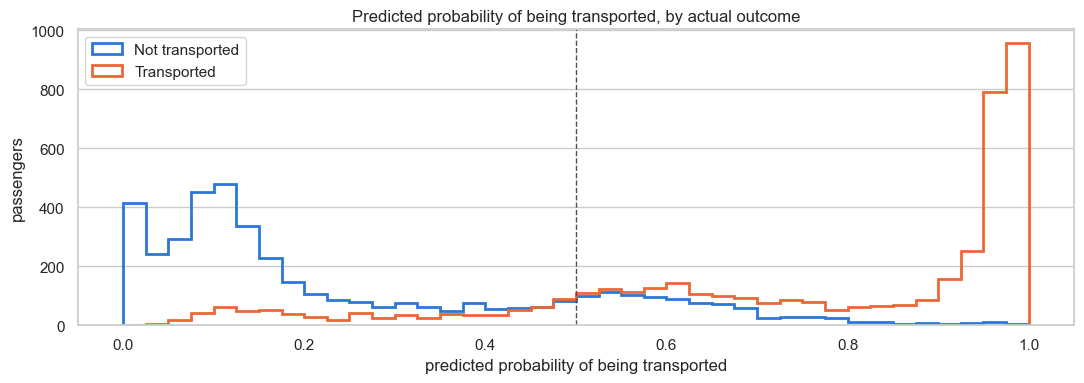

In [65]:
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(0, 1, 41)
for value in [0, 1]:
    ax.hist(err.loc[err["Transported"] == value, "proba"], bins=bins, histtype="step", linewidth=2,
            color=TARGET_COLORS[bool(value)], label=TARGET_LABELS[bool(value)])
ax.axvline(0.5, color=INK, linestyle="--", linewidth=1)
ax.set(title="Predicted probability of being transported, by actual outcome", xlabel="predicted probability of being transported", ylabel="passengers")
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Which passengers do the errors concentrate on?

In [66]:
err["state"] = np.select(
    [err["CryoSleep"].fillna(False).astype(bool), err["TotalSpend"] == 0],
    ["asleep", "awake, no spending"], "awake, spending",
)
overall = err["wrong"].mean() * 100


def error_by(col):
    g = err.groupby(col, observed=True)
    return pd.DataFrame({
        "passengers": g.size(),
        "transported %": g["Transported"].mean() * 100,
        "error %": g["wrong"].mean() * 100,
        "share of errors %": g["wrong"].sum() / err["wrong"].sum() * 100,
    }).round(1)


print(f"Overall error rate: {overall:.1f}%  ({err['wrong'].sum()} passengers)")
error_by("state")

Overall error rate: 18.5%  (1610 passengers)


,passengers,transported %,error %,share of errors %
state,,,,
asleep,3107,81.70,18.50,35.70
"awake, no spending",546,61.50,28.20,9.60
"awake, spending",5040,29.90,17.50,54.70


In [67]:
error_by("Deck")

,passengers,transported %,error %,share of errors %
Deck,,,,
A,262,50.40,16.80,2.70
B,796,73.20,5.70,2.80
C,761,68.10,5.70,2.70
D,487,43.30,13.60,4.10
E,885,36.00,22.00,12.10
F,2810,44.00,15.90,27.80
G,2588,51.60,28.90,46.50
T,5,20.00,0.00,0.00


In [68]:
pd.concat({"home planet": error_by("HomePlanet"), "age band": error_by("AgeGroup"), "side": error_by("Side")})

passengers  transported %  error %  share of errors %
home planet Earth         4708          42.40    26.10              76.40
            Europa        2175          66.00     7.40               9.90
            Mars          1805          52.40    12.10              13.60
age band    0-4            466          76.80    23.40               6.80
            13-17          739          55.30    15.70               7.20
            18-25         2351          45.80    20.50              29.90
            26-40         2887          48.00    15.80              28.40
            41-60         1511          49.50    19.00              17.80
            5-12           340          60.60    28.50               6.00
            61+            220          47.30    13.60               1.90
side        P             4251          45.20    19.60              51.70
            S             4343          55.60    17.40              47.00

In [69]:
# The hardest group: awake passengers who spent. Errors by amount spent
spenders = err[err["state"] == "awake, spending"].copy()
spenders["luxury spending"] = pd.cut(spenders["LuxurySpend"], [-1, 0, 100, 500, 1500, np.inf], labels=["0", "1-100", "101-500", "501-1500", "1500+"])
g = spenders.groupby("luxury spending", observed=True)
pd.DataFrame({"passengers": g.size(), "transported %": g["Transported"].mean() * 100, "error %": g["wrong"].mean() * 100}).round(1)

,passengers,transported %,error %
luxury spending,,,
0,204,64.70,29.90
1-100,643,65.90,33.10
101-500,849,43.50,21.80
501-1500,2069,21.40,15.80
1500+,1275,10.70,7.50


### 7.3 What does the model rely on?

**Permutation importance:** the values of one column are shuffled among the passengers and we look at how far accuracy drops. A large drop means the model leans on that column. Measured with the tuned CatBoost on the 5 validation sets of the first CV repeat.

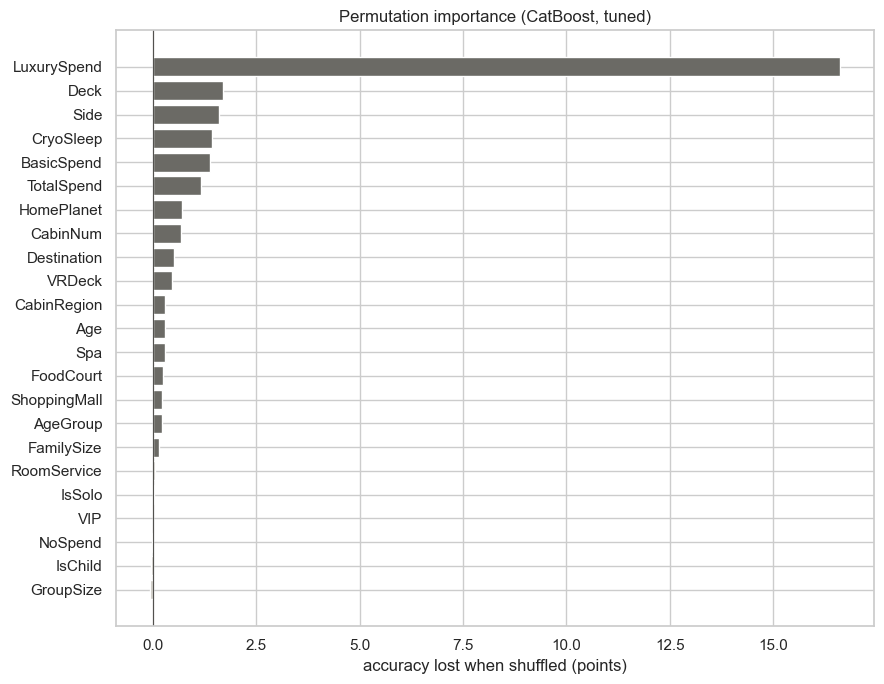

In [70]:
from sklearn.inspection import permutation_importance

X_frame = to_model_frame(X_fe_all, SPEC_ALL)
FEATURE_COLS = list(dict.fromkeys(sum(SPEC_ALL.values(), [])))
imps = []
for tr, va in SPLITS[:N_SPLITS]:
    pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", build_model("CatBoost", tuning["CatBoost"]["params"]))])
    pipe.fit(X_frame.iloc[tr], y[tr])
    r = permutation_importance(pipe, X_frame.iloc[va], y[va], scoring="accuracy", n_repeats=5, random_state=0,
                               n_jobs=1)
    imps.append(pd.Series(r.importances_mean, index=X_frame.columns))
importance = (pd.concat(imps, axis=1).mean(axis=1) * 100).loc[FEATURE_COLS].sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance.index, importance.values, color=[NEUTRAL if v > 0.05 else "#c9c7bf" for v in importance.values])
ax.axvline(0, color=INK, linewidth=0.8)
ax.set(title="Permutation importance (CatBoost, tuned)", xlabel="accuracy lost when shuffled (points)")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

**Verdict**

- **Two thirds of the errors sit with the passengers the model is unsure about.** The 2501 passengers with a probability between 0.3 and 0.7 account for 67% of all errors. On the 3644 passengers where the model is "very confident" it errs only 2.5% of the time. The model knows what it does not know; what is missing is information that separates the undecided passengers.
- **76% of the errors are Earthlings.** The error rate is 26% for Earthlings and 7% for Europans. The decks tell the same story: deck G (entirely Earthling) holds 47% of all errors at a 29% error rate, while decks B and C (Europans) err only 6% of the time.
- **Sleeping Earthlings are a hard group.** In 2.4 we saw 99% of sleeping Europans transported against only 66% of sleeping Earthlings. The model cannot tell a transported sleeping Earthling from one who stayed; the error rate among sleepers is 18.5%.
- **Light spenders who were awake are hard too.** Among awake passengers with 0–100 of luxury spending the error rate is 30–33%, against 7.5% for those spending over 1500.
- **Children:** 28.5% error at ages 5–12, 23% at 0–4.
- **The model leans most on luxury spending.** Shuffling that column costs 16.6 points of accuracy. Deck, side, CryoSleep and basic spending follow (1.2–1.7 points). Group size, travelling alone, VIP and the child flag are close to zero; the model already extracts them from other columns.
- **Why does CryoSleep look so unimportant?** Permutation importance is misleading for correlated columns. Even with CryoSleep shuffled, the model can recover the same information from "no spending" and from the luxury spending columns. That does not mean CryoSleep is unimportant.

**A hint for new features:** the errors pile up among Earthlings, especially on deck G and among sleepers. New information has to separate those passengers from each other.

### 7.4 What separates the Earthlings?

Most errors are Earthlings, especially on deck G. Here we look at cabin location together with deck, side and sleep state.

In [71]:
cab = err.copy()
cab["block"] = pd.cut(cab["CabinNum"], [-1, 299, 599, 899, 1199, 1499, 1999],
                     labels=["0-299", "300-599", "600-899", "900-1199", "1200-1499", "1500+"])
for deck in ["G", "F"]:
    d = cab[cab["Deck"] == deck]
    table = d.pivot_table(index="block", columns=["Side", "state"], values="Transported", aggfunc="mean", observed=True) * 100
    print(f"\nDeck {deck}: transported %")
    display(table.round(0))


Deck G: transported %


Side           P                                         S                     \
state     asleep awake, no spending awake, spending asleep awake, no spending   
block                                                                           
0-299      60.00              54.00           24.00  52.00              50.00   
300-599    62.00              44.00           18.00  55.00              39.00   
600-899    59.00              35.00           19.00  89.00              64.00   
900-1199   61.00              48.00           32.00  99.00              90.00   
1200-1499  56.00              43.00           16.00  66.00              59.00   
1500+      50.00                NaN           50.00    NaN                NaN   

Side                       
state     awake, spending  
block                      
0-299               22.00  
300-599             21.00  
600-899             45.00  
900-1199            68.00  
1200-1499           22.00  
1500+              100.00


Deck F: transported %


Side           P                                         S                     \
state     asleep awake, no spending awake, spending asleep awake, no spending   
block                                                                           
0-299     100.00             100.00           29.00 100.00             100.00   
300-599    97.00             100.00           20.00  94.00              67.00   
600-899    98.00             100.00           21.00 100.00             100.00   
900-1199   97.00              88.00           23.00 100.00             100.00   
1200-1499  97.00              83.00           21.00  95.00             100.00   
1500+     100.00              91.00           27.00  96.00             100.00   

Side                       
state     awake, spending  
block                      
0-299               25.00  
300-599             21.00  
600-899             47.00  
900-1199            48.00  
1200-1499           27.00  
1500+               21.00

In [72]:
lower = cab[cab["Deck"].isin(["F", "G"])]
pd.DataFrame({
    "passengers": lower.groupby("HotZone").size(),
    "transported %": lower.groupby("HotZone")["Transported"].mean() * 100,
    "model error %": lower.groupby("HotZone")["wrong"].mean() * 100,
}).rename(index={0.0: "F/G, outside the region", 1.0: "F/G, starboard 600–1199"}).round(1)

,passengers,transported %,model error %
HotZone,,,
"F/G, outside the region",4413,42.50,24.00
"F/G, starboard 600–1199",985,70.60,14.10


**Finding:** on the starboard side of deck G, in cabins 600–1199, 90–99% of the sleepers were transported; elsewhere on the same deck the rate is 53–66%. Among awake spenders the rate in that region is 2–3 times higher as well. On deck F the same region shows up among the awake. There is no such region to port.

The starboard peak from 2.2 is in fact **specific to the lower decks**. That is why the cabin region from Chapter 4 failed: the region only means something once deck × side × cabin number are combined. We hand that to the model as a single column: `HotZone`.

### 7.5 What does `HotZone` add?

In [73]:
SPEC_HZ = extend(SPEC_ALL, {"bool": ["HotZone"]})
X_fe_all = fe[is_train]  # the HotZone column has been added
PROBAS_HZ_PATH = TUNING_DIR / "split_probas_hotzone.pkl"
if PROBAS_HZ_PATH.exists():
    probas_hz = pickle.loads(PROBAS_HZ_PATH.read_bytes())
else:
    probas_hz = {n: split_probas(build_model(n, tuning[n]["params"]), SPEC_HZ) for n in TUNED_NAMES}
    PROBAS_HZ_PATH.write_bytes(pickle.dumps(probas_hz))

rows = []
pairs = [(n, probas[f"{n} (tuned)"], probas_hz[n]) for n in TUNED_NAMES]
pairs.append(("Ensemble: 4 boosting", blend(BOOSTED),
              [np.mean([probas_hz[n][i] for n in TUNED_NAMES], axis=0) for i in range(len(SPLITS))]))
for name, before_p, after_p in pairs:
    b, a = score_probas(before_p), score_probas(after_p)
    rows.append({"model": name, "before %": b["accuracy"].mean() * 100, "with HotZone %": a["accuracy"].mean() * 100,
                 "gain (points)": (a["accuracy"].mean() - b["accuracy"].mean()) * 100,
                 "p": corrected_ttest(b["accuracy"], a["accuracy"]),
                 "F1 %": a["f1"].mean() * 100, "ROC AUC %": a["roc_auc"].mean() * 100})
hz_table = pd.DataFrame(rows).set_index("model").round(3)
hz_table

,before %,with HotZone %,gain (points),p,F1 %,ROC AUC %
model,,,,,,
CatBoost,81.59,81.46,-0.12,0.55,81.71,90.86
LightGBM,81.32,81.37,0.05,0.77,81.61,90.69
XGBoost,81.16,81.20,0.04,0.86,81.61,90.54
HistGradientBoosting,81.31,81.38,0.06,0.81,81.76,90.72
Ensemble: 4 boosting,81.51,81.54,0.03,0.77,81.85,90.86


In [74]:
# Did the errors drop among Earthlings and on deck G?
ens_hz = [np.mean([probas_hz[n][i] for n in TUNED_NAMES], axis=0) for i in range(len(SPLITS))]
oof_hz = np.zeros((N_REPEATS, len(y)))
for i, ((tr, va), p) in enumerate(zip(SPLITS, ens_hz)):
    oof_hz[i // N_SPLITS, va] = p
err["wrong_hz"] = (oof_hz.mean(axis=0) >= 0.5).astype(int) != err["Transported"]

segments = {
    "everyone": err.index == err.index,
    "Earth": err["HomePlanet"] == "Earth",
    "deck G": err["Deck"] == "G",
    "deck F": err["Deck"] == "F",
    "inside HotZone": err["HotZone"] == 1,
    "Europa": err["HomePlanet"] == "Europa",
}
pd.DataFrame({
    name: {"passengers": m.sum(), "error % (before)": err.loc[m, "wrong"].mean() * 100,
           "error % (with HotZone)": err.loc[m, "wrong_hz"].mean() * 100,
           "errors (before)": err.loc[m, "wrong"].sum(), "errors (after)": err.loc[m, "wrong_hz"].sum()}
    for name, m in segments.items()
}).T.round(1)

,passengers,error % (before),error % (with HotZone),errors (before),errors (after)
everyone,"8,693.00",18.50,18.60,"1,610.00","1,614.00"
Earth,"4,708.00",26.10,26.20,"1,230.00","1,233.00"
deck G,"2,588.00",28.90,28.80,748.00,745.00
deck F,"2,810.00",15.90,16.00,448.00,450.00
inside HotZone,985.00,14.10,14.20,139.00,140.00
Europa,"2,175.00",7.40,7.30,160.00,159.00


In [75]:
path, checks = make_submission([build_model(n, tuning[n]["params"]) for n in TUNED_NAMES], SPEC_HZ,
                               "04_ensemble_hotzone.csv")
prev = pd.read_csv(SUBMISSION_DIR / "03_ensemble_4_boosting.csv")["Transported"]
checks["identical predictions to 03 %"] = round((pd.read_csv(path)["Transported"] == prev).mean() * 100, 1)
checks

rows (4277 expected)                         4277
columns match the sample file                True
PassengerId order matches the sample file    True
values are True/False                        True
missing values                                  0
predicted transported %                     52.60
identical predictions to 03 %               98.50
dtype: object

**Verdict: `HotZone` added nothing, because the model already knew about the region.**

- Across all models the difference runs from −0.12 to +0.06 points, none of it significant (p = 0.55–0.86). The ensemble went from 81.51 to 81.54: four passengers out of 8693.
- The hint was in the previous table and we missed it: the model's error rate is 14% inside the region and 24% outside it. The tree models had already found the region from deck, side and cabin number. The pattern we discovered was something the model **already knew**; it was not new information.
- **Where do the errors remain?** Among the sleeping Earthlings on deck G outside the region, 52–66% were transported. Cabin, age, destination and group do not tell those passengers apart; with the information we have, their outcome is a coin flip. The model is up against genuinely unpredictable uncertainty here.
- `04_ensemble_hotzone.csv` agrees with 03 on 98.5% of the test passengers, and it scored **0.80851** on the public leaderboard — as expected, no different.
- **The lesson:** a strong pattern found in exploration only raises the score if the model does not already know it. Before adding a feature, check whether the model actually errs on that pattern.

## Epilogue: What the Data Told Us, and What It Could Not

**What it told us.** Two things decide who was transported on the Spaceship Titanic: **what the passenger was doing** at the moment of impact, and **where they were**.

- 82% of those asleep in their pods were transported, against 30% of those walking the ship and spending.
- The kind of spending matters too: among heavy spenders at room service, the spa and the VR deck the rate falls as low as 5%.
- Location is the second factor: decks B and C (68–73%), the starboard side (56%) and cabins 600–1199 to starboard on the lower decks (71%).
- Passengers from Europa (66%) were transported more often than those from Earth (42%), but that is largely a reflection of which deck they lived on.
- Small children form their own group: 77% of those aged 0–4 were transported, against 46–50% of adults.

**What it could not tell us.** The model is wrong 18.5% of the time, and 76% of those errors are Earthlings, mostly on deck G. Most of them were asleep, and their transported rate sits between 52% and 66%. Cabin number, age, destination, group, family: none of these separates these people from each other. With the data we have, their outcome is a coin flip.

**What worked and what did not.** We tried five things and only one of them worked:

| Attempt | Result |
|---|---|
| Splitting spending into luxury and basic | ✅ +1.8 points for the linear model |
| Rule-based filling (73–100% accurate) | ❌ Only 2% of the values are missing, so the score did not move |
| Group, family, age and cabin-region features | ❌ The tree models already extract this from the raw columns |
| Hyperparameter search with Optuna | ❌ +0.3 points on the search CV, ~0 on independent splits |
| Ensembling and `HotZone` | ❌ The models already agree on 94–95% of the passengers |

That is the real lesson of this project: **the score is set by whether the information is new to the model, not by the model's settings.** Every strong pattern found in exploration teaches the model something only if it did not already know it — and it knew most of them.

**Result.** The best Kaggle score is **0.81038** (the average of four tuned gradient boosting models). Cross-validation said 81.51%; the 0.5 point gap sits inside the variation that comes from scoring the leaderboard on roughly 2100 passengers. The version with `HotZone` scored 0.80851 — as expected, no difference.